# Прогнозирование поведения клиента (ДЗ)

Привет!

В этом домашнем задании тебе предстоит построить кривые def rate, внедрить def rate в NPV-модель и исследовать зависимость обновленной модели от выбранного скора (подробные пункты перечислены ниже).

Для выполнения тебе понадобится выборка с данными, которую использовали на семинаре (**data_vintages.csv**), x_score и PD (**data_scores.csv**). Не бойся выходить за рамки методов, предлженных в лекции.

Главное - не забывай **аргументировать** свой выбор и давать **комментарии** своим действиям. 

Удачи!

#### Как будет оцениваться работа:
За это ДЗ ты можешь получить максимум **10 баллов**. Все пункты весят по-разному, баллы указаны рядом с пунктами. Баллы могут сниматься в случае неполного выполнения задания или отсутствия аргументации.


#### Задачи:

1) Построить кривые DEF rate (5 баллов)
    - Выбрать переменную для разбивки по бакетам (0.5 балла)
    - Провести анализ поколений (0.5 балла)
    - Построить винтажи DEF rate (0.5 балла)
    - Провести анализ на особые точки (0.5 балла)
    - Провести анализ наличия внешних воздействий и при необходимости вычистить кривые (2 балла)
    - Построить среднее по винтажам для каждого бакета (0.5 балла)
    - Сгладить кривые (0.5 балла)
    
2) Внести в модель построенную кривую DEF rate и исследовать зависимость от скора (5 баллов)
    - Реализовать метод для расчета DEF rate по поданному скору (3 балла)
    - Рассчитать NPV для кредита с заданными параметрами (1 балл)
    - Построить кривую зависимости NPV от скора (1 балл)
    
**Пожалйуста, аргументируйте свои решения по каждому пункту**

В качестве результата приложи текущий ноутбук с названием 'Surname_def.ipynb'

## Кривые DEF rate

#### Выгружаем данные с винтажами

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from sklearn.metrics import r2_score

In [91]:
# В качестве данных для винтажей используй файл с семинара data_vintages.csv
df = pd.read_csv('data_vintages.csv', sep=';', index_col=0)
print("Размер таблицы scores:", df.shape)
print(df.columns.to_list())
df.head()

Размер таблицы scores: (2493268, 12)
['user_id', 'statement_num', 'gen_month_dt', 'gen_quarter_dt', 'clo_flg', 'def_flg', 'dlq_flg', 'act_flg', 'prev_clo_flg', 'prev_def_flg', 'prev_dlq_flg', 'prev_act_flg']


,user_id,statement_num,gen_month_dt,gen_quarter_dt,clo_flg,def_flg,dlq_flg,act_flg,prev_clo_flg,prev_def_flg,prev_dlq_flg,prev_act_flg
0,127336,19,2019-07-01,2019-07-01,0,0,0,1,0,0,0,1
1,35907,16,2019-04-01,2019-04-01,1,0,0,0,1,0,0,0
2,45228,21,2019-05-01,2019-04-01,0,0,0,1,0,0,0,1
3,39035,23,2019-07-01,2019-07-01,0,0,0,1,0,0,0,1
4,130780,19,2019-08-01,2019-07-01,1,0,0,0,1,0,0,0


In [92]:
print("\nКоличество поколений:")
print(df["gen_month_dt"].nunique())

print("\nПериод поколений:")
print(df["gen_month_dt"].min(), "—", df["gen_month_dt"].max())

print("\nКоличество месяцев жизни:")
print(df["statement_num"].min(), "—", df["statement_num"].max())


Количество поколений:
14

Период поколений:
2019-02-01 — 2020-03-01

Количество месяцев жизни:
1 — 24


#### Выгружаем данные со скорами для дальнейшей разбивки на бакеты

In [93]:
df_scores = pd.read_csv("data_scores.csv", sep=";", index_col=0)

print(df_scores.head())
print("Размер таблицы scores:", df_scores.shape)
print(df_scores.columns.tolist())
df_scores.info()


   user_id                   pd            x_score
0     9311   0,0350254739064704   0,21997952026375
1   155026   0,0462786374437515  0,146985822716473
2    17584  0,00722132437757033  0,343298452691632
3   156231   0,0696789392388602  0,186684369950882
4   123587   0,0104023340794164  0,305581817696171
Размер таблицы scores: (104820, 3)
['user_id', 'pd', 'x_score']
<class 'pandas.DataFrame'>
RangeIndex: 104820 entries, 0 to 104819
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   user_id  104820 non-null  int64
 1   pd       104820 non-null  str  
 2   x_score  104820 non-null  str  
dtypes: int64(1), str(2)
memory usage: 5.9 MB


#### Бъем выборку на бакеты и джойним с данными с винтажами

In [94]:
# Разбей данные на бакеты по каждой переменной (базовый набор бакетов - 3)

df_scores['pd'] = df_scores['pd'].str.replace(',', '.').astype(float)
df_scores['x_score'] = df_scores['x_score'].str.replace(',', '.').astype(float)

df_scores = df_scores.copy()
n = len(df_scores)

# PD
df_scores = df_scores.sort_values("pd").reset_index(drop=True)
df_scores["pd_bucket"] = np.minimum(df_scores.index // (n // 3), 2)

print("Средний PD по бакетам:")
print(df_scores.groupby("pd_bucket")["pd"].agg(["count", "mean", "min", "max"]))

# X score
df_scores = df_scores.sort_values("x_score").reset_index(drop=True)
df_scores["x_bucket"] = np.minimum(df_scores.index // (n // 3), 2)

print("\nСредний X_score по бакетам:")
print(df_scores.groupby("x_bucket")["x_score"].agg(["count", "mean", "min", "max"]))

Средний PD по бакетам:
           count      mean       min       max
pd_bucket                                     
0          34940  0.011040  0.000252  0.020798
1          34940  0.032685  0.020798  0.046316
2          34940  0.068209  0.046317  0.099997

Средний X_score по бакетам:
          count      mean       min       max
x_bucket                                     
0         34940  0.133270  0.039711  0.176967
1         34940  0.220838  0.176968  0.272747
2         34940  0.379452  0.272748  0.793186


In [95]:
# джоиним скор к винтажам
df = df.merge(
    df_scores[
        ["user_id", "pd_bucket", "x_bucket", "pd", "x_score"]
    ],
    how="left",
    on="user_id"
).dropna(subset=["pd_bucket", "x_bucket"])

print("Размер объединенной выборки:", df.shape)
df.head()

Размер объединенной выборки: (2493268, 16)


,user_id,statement_num,gen_month_dt,gen_quarter_dt,clo_flg,def_flg,dlq_flg,act_flg,prev_clo_flg,prev_def_flg,prev_dlq_flg,prev_act_flg,pd_bucket,x_bucket,pd,x_score
0,127336,19,2019-07-01,2019-07-01,0,0,0,1,0,0,0,1,1,2,0.021296,0.469410
1,35907,16,2019-04-01,2019-04-01,1,0,0,0,1,0,0,0,2,0,0.064742,0.157215
2,45228,21,2019-05-01,2019-04-01,0,0,0,1,0,0,0,1,0,2,0.018490,0.469583
3,39035,23,2019-07-01,2019-07-01,0,0,0,1,0,0,0,1,1,1,0.025882,0.210896
4,130780,19,2019-08-01,2019-07-01,1,0,0,0,1,0,0,0,1,1,0.024330,0.269492


### Выбери переменную, которая делит кривые наилучшим образом (0.5 баллов)

 Из двух скоров (x_score и ваш PD) выбери тот, который разделяет кривые наилучшим образом

Сначала определим функцию для расчета DEF-rate по следующей формуле:
$$ DEFRate_n = \frac{\text{новые дефолты в } n}{\text{активные клиенты в } n - 1} $$


In [96]:
def calculate_def_rate(data, group_col=None):
    
    group_cols = []

    if group_col is not None:
        group_cols.append(group_col)

    group_cols += ["gen_month_dt", "statement_num"]
    
    tmp = (
        data
        .groupby(group_cols, as_index=False)
        .agg(
            def_cnt=("def_flg", "sum"),
            act_cnt=("act_flg", "sum"),
            user_cnt=("user_id", "count")
        )
    )

    # Количество активных клиентов предыдущего месяца
    if group_col is not None:
        tmp["act_prev_cnt"] = (
            tmp
            .sort_values([group_col, "gen_month_dt", "statement_num"])
            .groupby([group_col, "gen_month_dt"])["act_cnt"]
            .shift(1)
        )
    else:
        tmp["act_prev_cnt"] = (
            tmp
            .sort_values(["gen_month_dt", "statement_num"])
            .groupby("gen_month_dt")["act_cnt"]
            .shift(1)
        )

    # DEF rate
    tmp["def_rate"] = (
        tmp["def_cnt"] / tmp["act_prev_cnt"]
    )

    # Первый месяц не имеет предыдущего месяца
    tmp.loc[
        tmp["statement_num"] == tmp["statement_num"].min(),
        "def_rate"
    ] = np.nan

    return tmp

In [97]:
#  Строим среднюю DEF rate-кривую для трех бакетов выбранного параметра.
def plot_def_rate_by_bucket(data, bucket):

    def_data = calculate_def_rate(data, group_col=bucket)

    curves = (
        def_data
        .groupby([bucket, "statement_num"])["def_rate"]
        .mean()
        .unstack(bucket)
    )

    ax = curves.plot(
        figsize=(14, 8),
        grid=True,
        lw=2
    )

    plt.title(
        f"DEF rate по бакетам: {bucket}",
        fontsize=18
    )
    plt.xlabel("Месяц жизни кредита")
    plt.ylabel("DEF rate")
    plt.legend(
        title="Бакет",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()

    plt.show()
    return curves

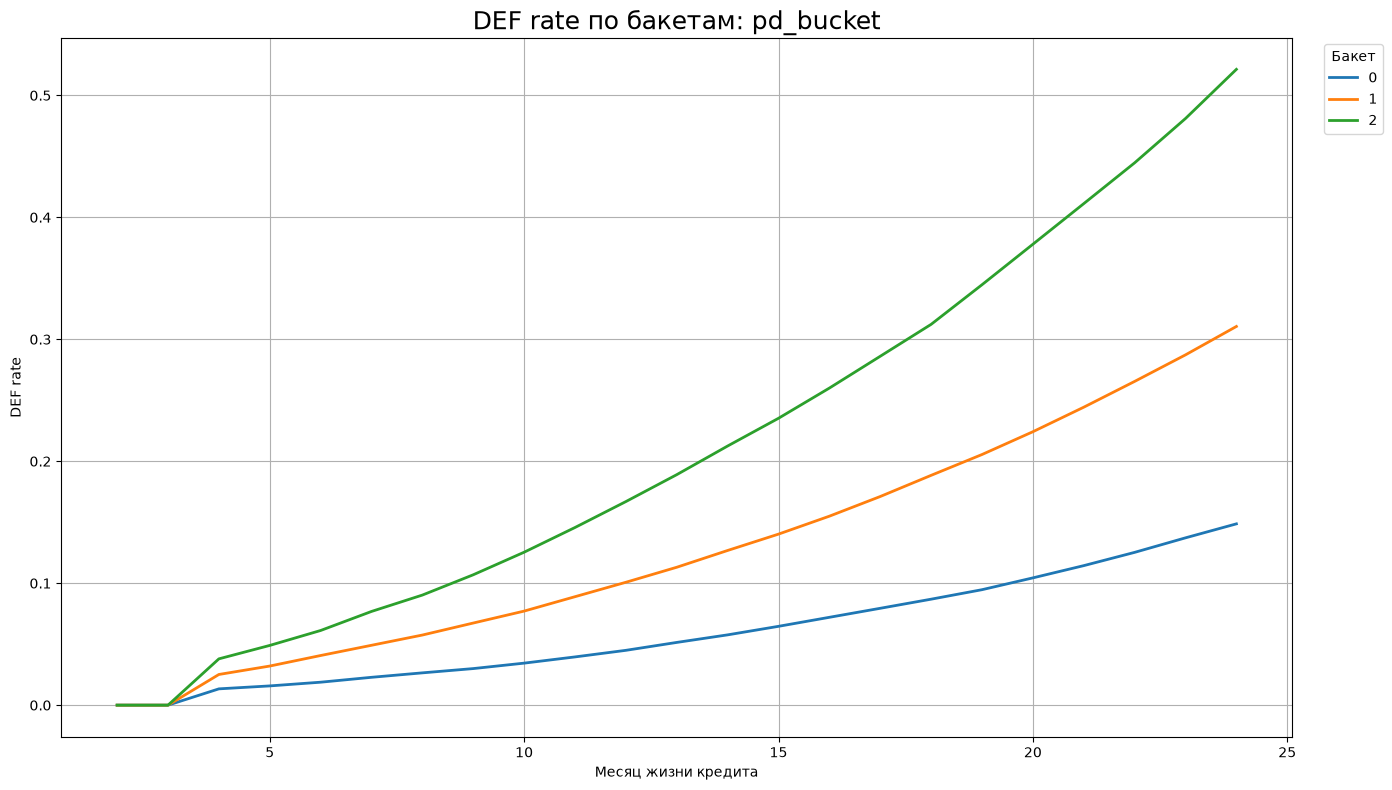

In [98]:
def_curves_pd = plot_def_rate_by_bucket(
    df,
    "pd_bucket"
)

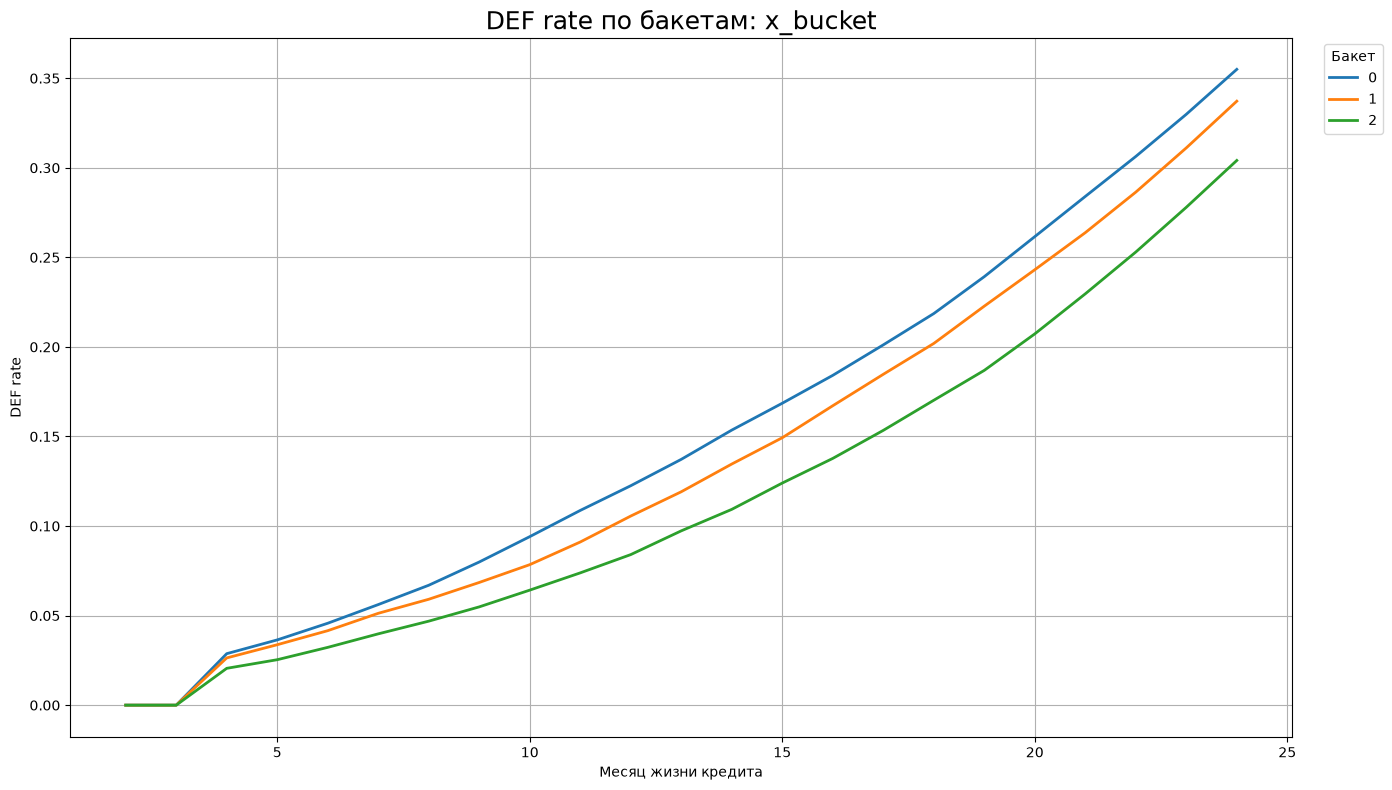

In [99]:
def_curves_x = plot_def_rate_by_bucket(
    df,
    "x_bucket"
)

#### Вывод: здесь укажи выбранную тобой переменную и обоснуй свой выбор

Из графика уже очевидно, что стоит использовать PD для сегментации бакетов, так как оно обеспечивает большее расстояние между DEF rate кривыми трех бакетов.

### Анализ поколений (0.5 баллов)

Отрисуй распределение данных во времени в разбивке по выбранной перменной

In [100]:
def plot_distribution(data, bucket):
    distribution = (
        data
        .groupby(["gen_month_dt", bucket])["user_id"]
        .nunique()
        .unstack(bucket)
        .fillna(0)
    )

    ax = distribution.plot(
        kind="bar",
        stacked=True,
        figsize=(15, 8)
    )

    plt.title(
        f"Распределение клиентов по поколениям: {bucket}",
        fontsize=18
    )
    plt.xlabel("Поколение")
    plt.ylabel("Количество клиентов")
    plt.legend(
        title="Бакет",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()

    return distribution

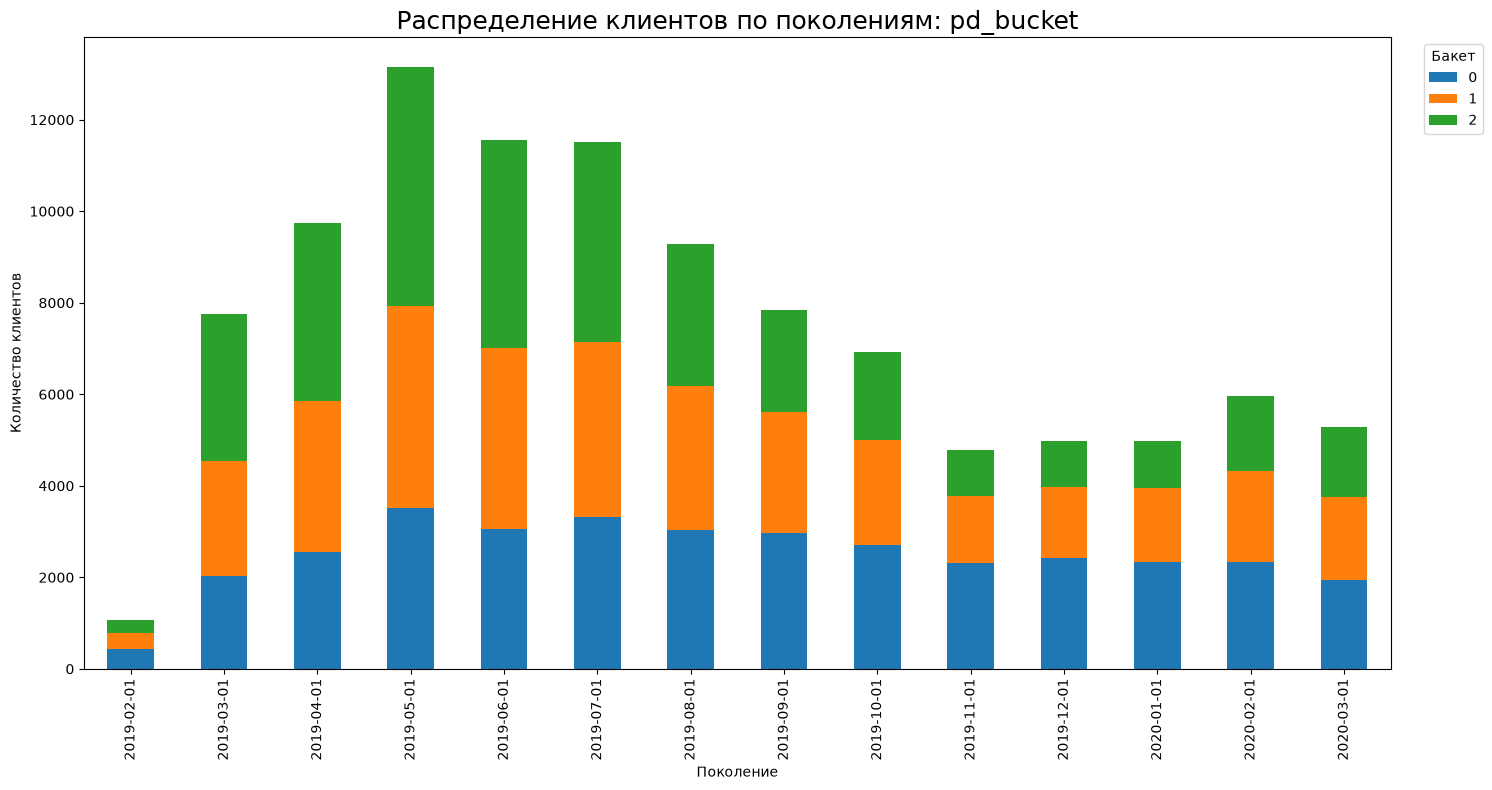

In [101]:
generation_distribution = plot_distribution(
    df,
    'pd_bucket'
)

In [102]:
# Исключаем поколение за февраль 2019 года
df = df[df['gen_month_dt'] != '2019-02-01']

In [103]:
print("Оставшиеся поколения:", df['gen_month_dt'].unique())

Оставшиеся поколения: <ArrowStringArray>
['2019-07-01', '2019-04-01', '2019-05-01', '2019-08-01', '2019-03-01',
 '2019-06-01', '2019-11-01', '2020-01-01', '2019-09-01', '2020-02-01',
 '2019-10-01', '2020-03-01', '2019-12-01']
Length: 13, dtype: str


#### Вывод: сделай выводы по полученным графикам. Нужно ли исключать какие-то бакеты/поколения? Если да, то реализуй их исключение из выборки

По той же логике, что и на семинаре исключим из дальнейшего рассмотрения поколение с февраля 2019 года из-за малочисленности выборки. Насчет бакетов: не думаю, что стоит исключать поколение 2 из рассмотрения, хотя оно и сильнее всего меняется в численности, так как он отражает поведение высокорискованных клиентов, критически важное для оценки NPV

### Кривые DEF Rate в разбивке по бакетам (0.5 баллов)

Реализуй функцию, которая отрисовывает винтажи DEF rate в разбивке по бакетам

In [ ]:
def plot_def_rate_by_generation(data, bucket, bucket_value):
    
    data_bucket = data[data[bucket] == bucket_value].copy()
    def_data = calculate_def_rate(data_bucket)

    vintages = (def_data.pivot(
            index="statement_num",
            columns="gen_month_dt",
            values="def_rate"
        )
    )

    ax = vintages.plot(
        figsize=(15, 9),
        grid=True,
        lw=1.5,
        alpha=0.7
    )

    plt.title(f"Винтажи DEF rate, {bucket} = {bucket_value}",fontsize=18)
    plt.xlabel("Месяц жизни кредита")
    plt.ylabel("DEF rate")
    plt.legend(
        title="Поколение",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()

    return vintages

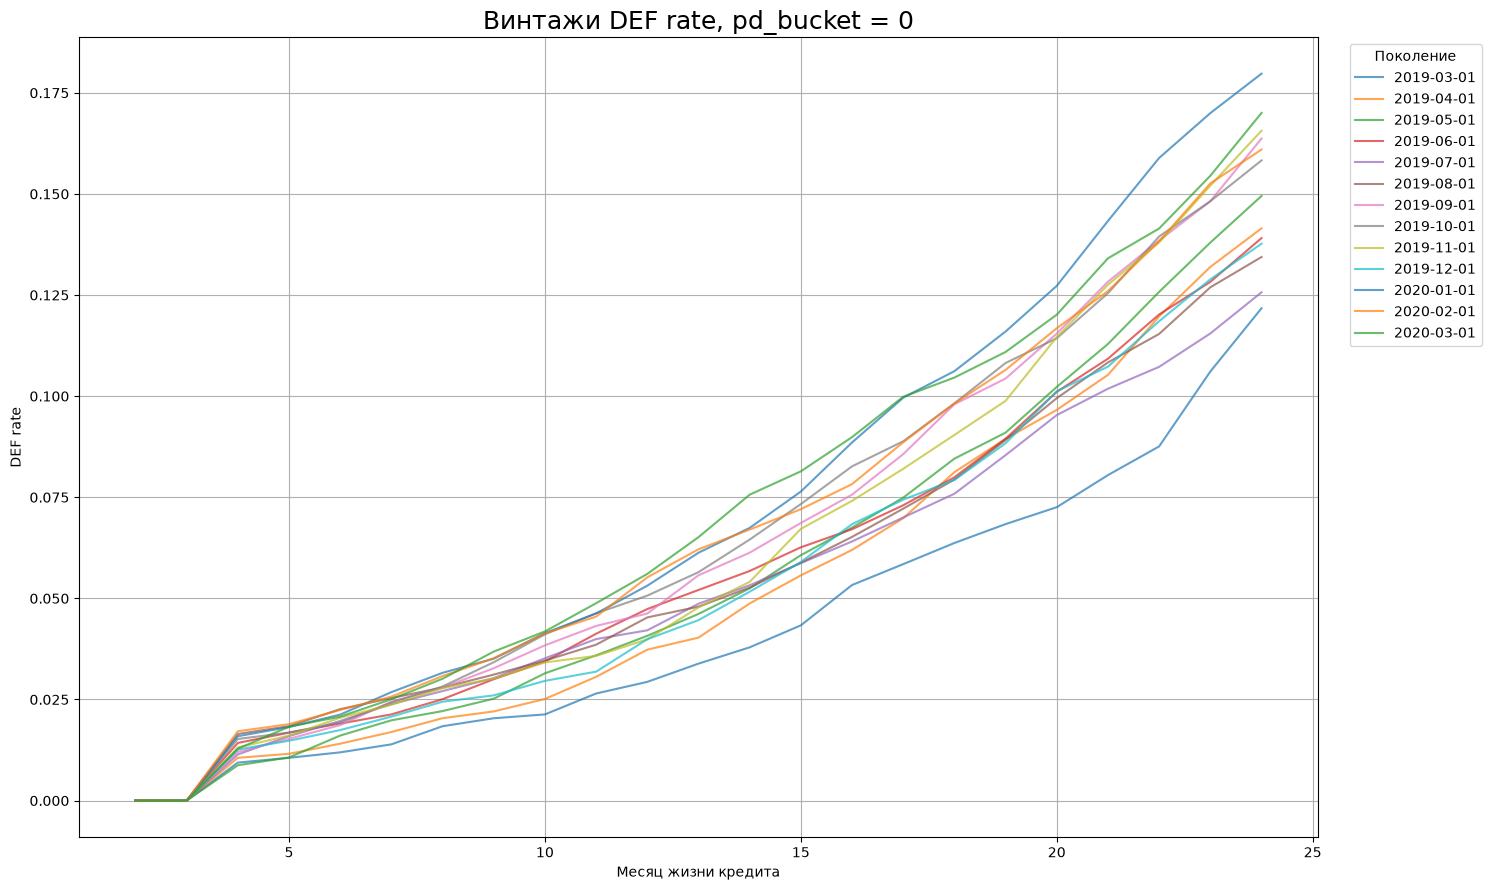

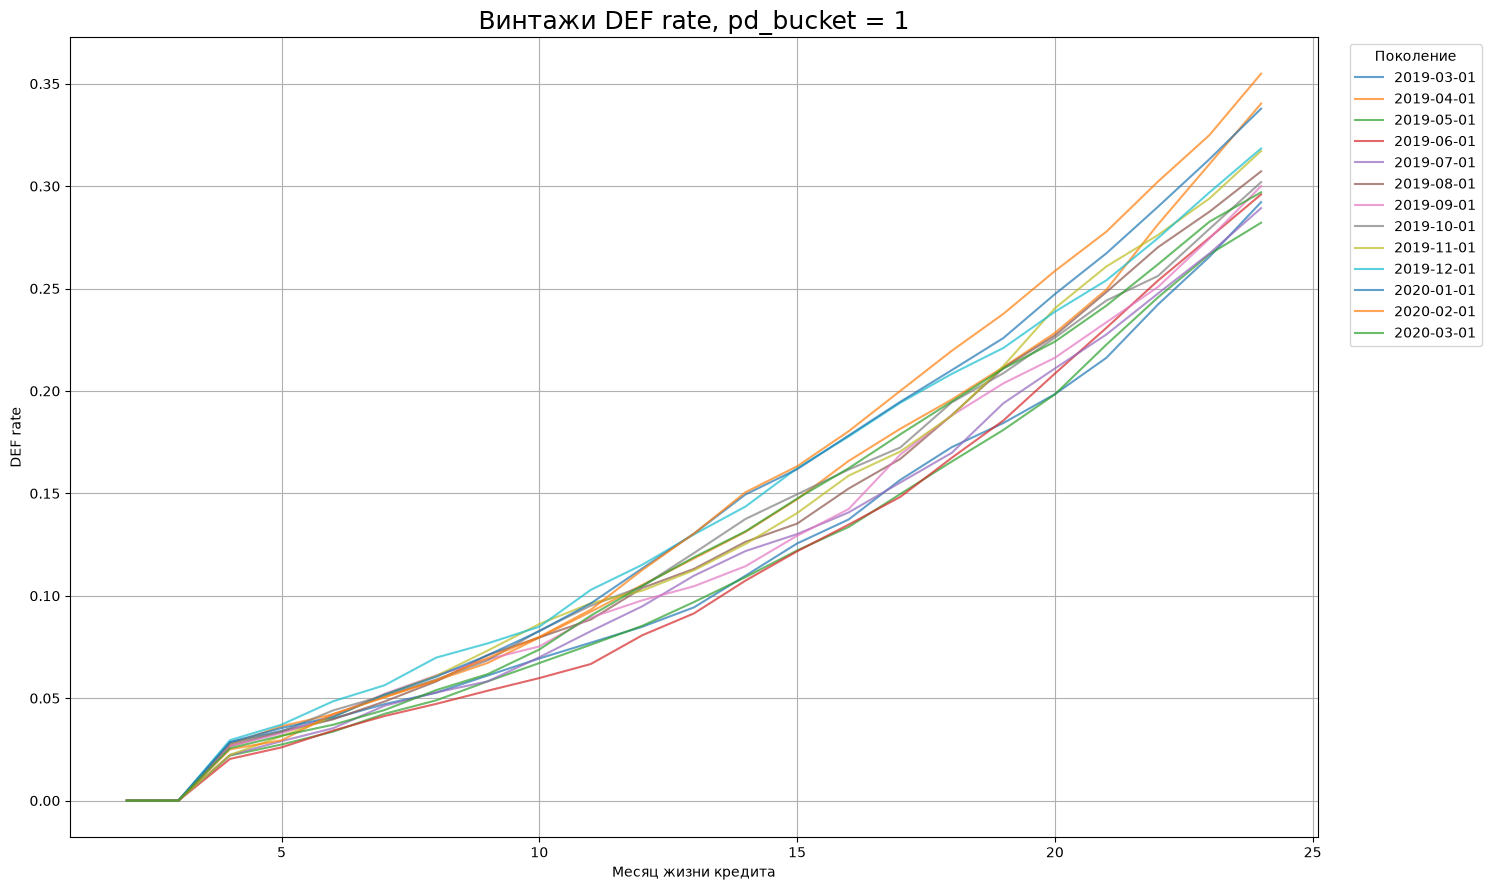

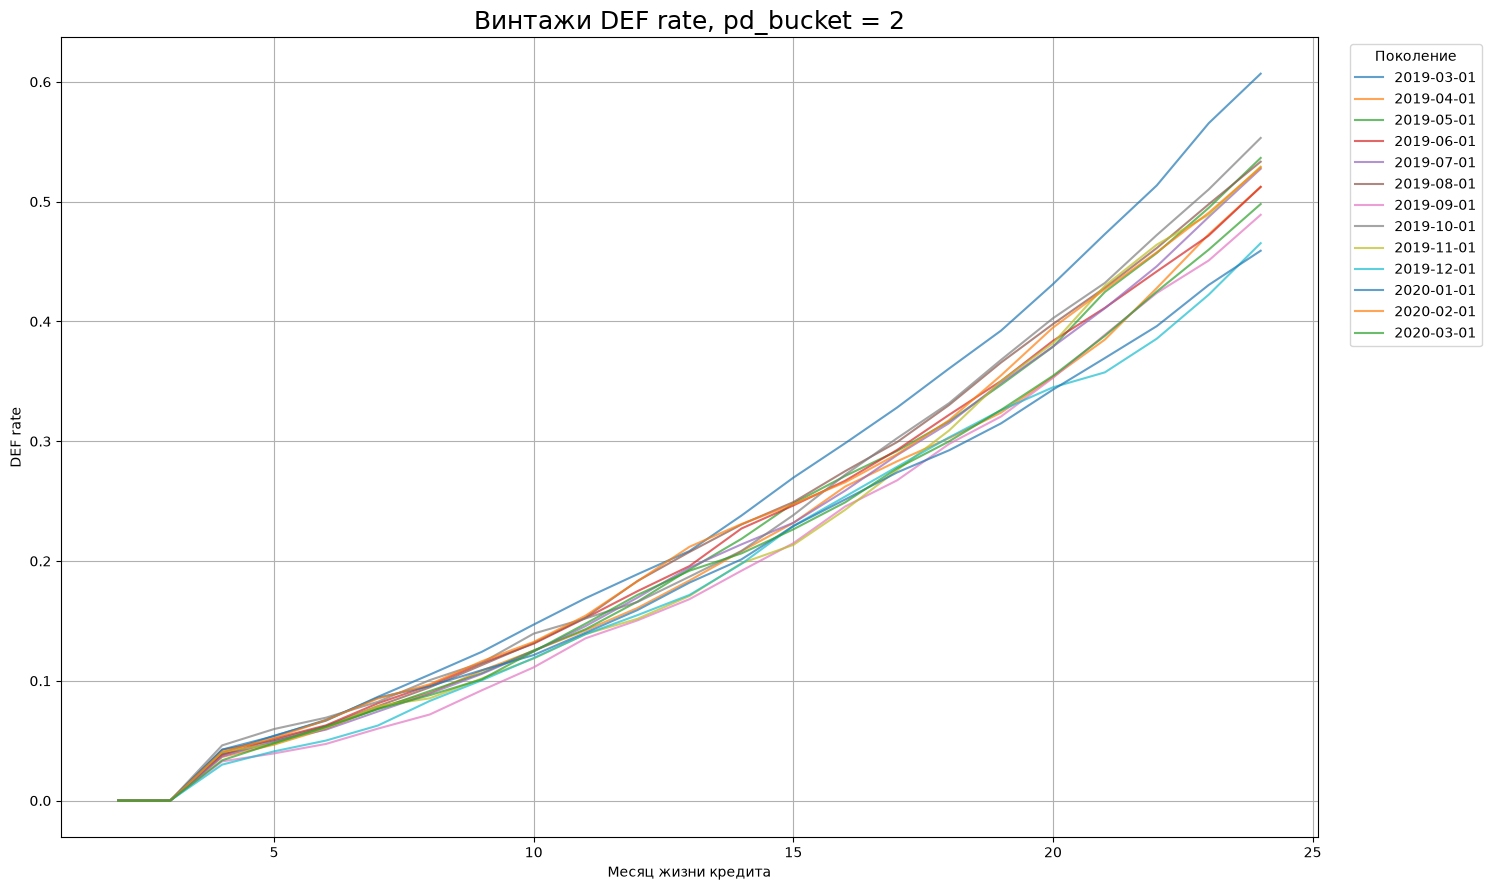

In [ ]:
buckets = sorted(df['pd_bucket'].dropna().unique())
def_vintages = {}

for bucket_value in buckets:
    def_vintages[bucket_value] = plot_def_rate_by_generation(
        df,
        'pd_bucket',
        bucket_value
    )

#### Выводы: сделай выводы по полученным графикам


На всех винтажах видно, что поколения сильно друг от друга не отличаются: одинаковый восходящий тренд. Разница лишь в абсолютных значениях DEF rate по бакетам.


### Особые точки (0.5 баллов) 
#### Есть ли в винтажах особые точки? Укажи их. Какова их природа? Нужно ли их исключать?



In [106]:
def find_vintage_outliers(vintage_dict, z_threshold=3):

    result = []

    for bucket_value, vintage_table in vintage_dict.items():
        for generation in vintage_table.columns:

            series = vintage_table[generation].dropna()

            if len(series) < 5:
                continue

            mean = series.mean()
            std = series.std()

            if std == 0 or pd.isna(std):
                continue

            z_scores = (series - mean) / std
            outliers = series[
                z_scores.abs() > z_threshold
            ]

            for month, value in outliers.items():
                result.append({
                    "bucket": bucket_value,
                    "generation": generation,
                    "statement_num": month,
                    "def_rate": value,
                    "z_score": z_scores.loc[month]
                })

    return pd.DataFrame(result)



outliers = find_vintage_outliers(def_vintages)

if len(outliers) > 0:
    outliers = outliers.sort_values(
        "z_score",
        key=lambda x: x.abs(),
        ascending=False
    ).head(20)
else:
    print("Выбросов не найдено")

Выбросов не найдено


Явных статистических выбросов по выбранному критерию не обнаружено. Поэтому дополнительные точки из выборки не исключаем.

### Макроэкономические воздействие (2 балла)

#### Есть ли в винтажах DEF rate макроэкономическое воздействие (нарисуй график иллюстрирующее это воздействие)? Если да, то предположи какое событие его вызвало и почему?
#### В случае наличия внешнего влияния 
#### 1) Разложи кривые на внешнее воздействие и созревание кривых
#### 2) Отрисуй график внешнего воздествия
#### 3) Отрисуй вычищенные винтажи DEF rate в разбивке по бакетам
#### 4) Посчитай среднее для этих бакетов и реализуй сглаживание

Будем использовать ту же идею, что и на семинаре

$$
D(t,n) = E(t) \cdot M(t - n).
$$

$E$ — календарное внешнее воздействие, 
$M$ — чистая кривая созревания клиента.


In [128]:
# Приводим даты к datetime
df["gen_month_dt"] = pd.to_datetime(df["gen_month_dt"], errors="coerce")
df["gen_quarter_dt"] = pd.to_datetime(df["gen_quarter_dt"], errors="coerce")

# Проверяем результат
print(df[["gen_month_dt", "gen_quarter_dt"]].dtypes)
print("\nКоличество некорректно распарсенных дат:")
print(df[["gen_month_dt", "gen_quarter_dt"]].isna().sum())

gen_month_dt      datetime64[us]
gen_quarter_dt    datetime64[us]
dtype: object

Количество некорректно распарсенных дат:
gen_month_dt      0
gen_quarter_dt    0
dtype: int64


In [ ]:
def curve_build(
    data,
    feature="def_rate",
    generation="gen_month_dt",
    statement_num="statement_num",
    group_label="1",
    stable_from=6
):
    
    df_query = data.copy()

    # Подготовка данных
    df_query[generation] = pd.to_datetime(df_query[generation], errors="coerce")

    if df_query[generation].isna().any():
        raise ValueError(
            f"В {generation} обнаружены некорректные даты."
        )

    
    # Подготовка statement_num
    df_query[statement_num] = pd.to_numeric(df_query[statement_num], errors="coerce")

    if df_query[statement_num].isna().any():
        raise ValueError(
            f"В {statement_num} обнаружены некорректные значения."
        )

    df_query[statement_num] = (df_query[statement_num].astype(int))


    # DEF rate должен быть числовым
    df_query[feature] = pd.to_numeric(df_query[feature], errors="coerce")

    
    # Удаляем наблюдения, для которых DEF rate невозможно использовать
    df_query = df_query[np.isfinite(df_query[feature])].copy()

    if len(df_query) == 0:
        raise ValueError(
            "После удаления NaN/inf не осталось "
            "ни одного наблюдения для оптимизации."
        )


    # Сортировка
    df_query = (
        df_query
        .sort_values(
            [generation, statement_num]
        )
        .reset_index(drop=True)
    )

    df_query["month_dt"] = [
        gen_date
        + pd.DateOffset(
            months=int(month_num) - 1
        )
        for gen_date, month_num
        in zip(
            df_query[generation],
            df_query[statement_num]
        )
    ]

    df_query["month_dt"] = pd.to_datetime(
        df_query["month_dt"]
    )

    # Проверяем
    if df_query["month_dt"].isna().any():
        raise ValueError(
            "При расчете month_dt появились NaT."
        )

    # Формируем индексы
    min_month = df_query["month_dt"].min()
    max_month = df_query["month_dt"].max()

    # Количество календарных месяцев
    T = (
        (max_month.year - min_month.year) * 12
        + (max_month.month - min_month.month)
        + 1
    )

    # Максимальный возраст кредита
    A = (
        df_query[statement_num].max()
    )

    # Индекс календарного месяца
    df_query["calendar_month_idx"] = (
        (
            df_query["month_dt"].dt.year
            - min_month.year
        ) * 12
        + (
            df_query["month_dt"].dt.month
            - min_month.month
        )
    ).astype(int)

    
    # Индекс возраста кредита
    df_query["age_idx"] = (df_query[statement_num] - 1).astype(int)

    
    # Проверки индексов
    if (
        df_query["calendar_month_idx"].min() < 0
        or df_query["calendar_month_idx"].max() >= T
    ):
        raise ValueError(
            "Ошибка в calendar_month_idx."
        )

    if (
        df_query["age_idx"].min() < 0
        or df_query["age_idx"].max() >= A
    ):
        raise ValueError(
            "Ошибка в age_idx."
        )

    # Наблюдаемые значения D(t,n)
    values = (
        df_query[feature]
        .to_numpy(dtype=float)
    )

    dates = (
        df_query["calendar_month_idx"]
        .to_numpy(dtype=int)
    )

    age = (
        df_query["age_idx"]
        .to_numpy(dtype=int)
    )

    
    # Проверяем отсутствие NaN
    if not np.all(np.isfinite(values)):
        raise ValueError(
            "В values остались NaN или inf."
        )

    
    # Функция распаковки параметров
    def unpack_x(x):

        E_raw = x[:T]
        M_raw = x[T:T + A]

        # Нормируем E(t)
        stable_indices = np.arange(T) >= stable_from

        if stable_indices.sum() > 0:
            mean_E = np.mean(
                E_raw[stable_indices]
            )
        else:
            mean_E = np.mean(E_raw)

        if (
            not np.isfinite(mean_E)
            or abs(mean_E) < 1e-12
        ):
            mean_E = 1.0

        E = E_raw / mean_E

        # Компенсируем нормировку в M
        M = M_raw * mean_E

        return E, M

    # Функция ошибки
    def objective(x):

        E, M = unpack_x(x)

        prediction = (
            E[dates]
            * M[age]
        )

        residuals = (
            values
            - prediction
        )

        return np.sum(
            residuals ** 2
        )

    
    # Начальное приближение
    x0 = np.ones(
        T + A,
        dtype=float
    )

    
    # Оптимизация
    result = minimize(
        objective,
        x0,
        method="Powell",
        options={
            "maxiter": 5000,
            "xtol": 1e-10,
            "ftol": 1e-10
        }
    )

    
    # Проверка результата оптимизации
    if not np.isfinite(result.fun):
        raise ValueError(
            "Оптимизация завершилась с NaN/inf "
            "в значении целевой функции."
        )


    # Получаем E(t) и M(n)
    E_hat, M_hat = unpack_x(
        result.x
    )

    # Формируем E(t)
    external_dates = pd.date_range(
        start=min_month,
        periods=T,
        freq="MS"
    )

    external_data = pd.DataFrame({
        "month_dt": external_dates,
        str(group_label): E_hat
    })

    
    # Формируем M(n)
    maturation_data = pd.DataFrame({
        statement_num: np.arange(
            1,
            A + 1
        ),
        str(group_label): M_hat
    })

    # Присоединяем E(t)
    df_fitted = df_query.merge(
        external_data,
        on="month_dt",
        how="left"
    )

    # Очищенная кривая
    df_fitted["fitted_feature"] = (
        df_fitted[feature]
        / df_fitted[str(group_label)]
    )

    return {
        "result": result,
        "external_data": external_data,
        "maturation_data": maturation_data,
        "fitted_data": df_fitted
    }

In [121]:
# Применим функцю разложения ко всем бакетам
# Cначала агрегируем клиентские наблюдения, затем рассчитываем DEF rate
def build_def_rate_data(data, bucket):
   
    grouped = (
        data
        .groupby(
            [
                bucket,
                "gen_month_dt",
                "statement_num"
            ],
            as_index=False
        )
        .agg(
            def_cnt=("def_flg", "sum"),
            act_cnt=("act_flg", "sum"),
            user_cnt=("user_id", "count")
        )
    )

    grouped = grouped.sort_values(
        [bucket, "gen_month_dt", "statement_num"]
    )

    # Активные в предыдущем месяце
    grouped["act_prev_cnt"] = (
        grouped
        .groupby([bucket, "gen_month_dt"])["act_cnt"]
        .shift(1)
    )

    grouped["def_rate"] = (grouped["def_cnt"] / grouped["act_prev_cnt"])
    grouped.loc[grouped["statement_num"] == 1, "def_rate"] = np.nan

    return grouped


df_def = build_def_rate_data(
    df,
    'pd_bucket'
)

df_def.head()

,pd_bucket,gen_month_dt,statement_num,def_cnt,act_cnt,user_cnt,act_prev_cnt,def_rate
0,0,2019-03-01,1,0,1871,2020,NaN,NaN
1,0,2019-03-01,2,0,1792,2020,1871.0,0.000000
2,0,2019-03-01,3,0,1703,2020,1792.0,0.000000
3,0,2019-03-01,4,16,1607,2016,1703.0,0.009395
4,0,2019-03-01,5,17,1509,2016,1607.0,0.010579


In [ ]:
def decomposition(
    data,
    bucket,
    feature="def_rate"
):
  
    data = data.copy()

  
    # Типы данных
    data["gen_month_dt"] = pd.to_datetime(
        data["gen_month_dt"],
        errors="coerce"
    )

    data["statement_num"] = pd.to_numeric(
        data["statement_num"],
        errors="coerce"
    )

    data[feature] = pd.to_numeric(
        data[feature],
        errors="coerce"
    )

    external_results = []
    maturation_results = []
    fitted_results = []

    
    # Бакеты
    bucket_values = sorted(
        data[bucket]
        .dropna()
        .unique()
    )

    # Обрабатываем каждый бакет
    for bucket_value in bucket_values:

        print(f"Обрабатываем бакет: {bucket_value}")

        data_bucket = data[data[bucket] == bucket_value].copy()
        result = curve_build(
            data=data_bucket,
            feature=feature,
            generation="gen_month_dt",
            statement_num="statement_num",
            group_label=str(bucket_value),
            stable_from=6
        )

        # E(t)
        ext = result["external_data"].copy()
        external_results.append(ext)

        # M(n)
        mat = result["maturation_data"].copy()
        maturation_results.append(mat)

        
        # Очищенные данные
        fitted = result["fitted_data"].copy()
        fitted[bucket] = bucket_value
        fitted_results.append(fitted)

    # Объединяем E(t)
    external_data = external_results[0].copy()
    for ext in external_results[1:]:
        external_data = external_data.merge(ext, on="month_dt", how="outer")

    
    # Объединяем M(n)
    maturation_data = (maturation_results[0].copy())

    for mat in maturation_results[1:]:
        maturation_data = maturation_data.merge(
            mat,
            on="statement_num",
            how="outer"
        )

    
    # Объединяем очищенные данные
    fitted_data = pd.concat(
        fitted_results,
        ignore_index=True
    )

    return {
        "external_data": external_data,
        "maturation_data": maturation_data,
        "fitted_data": fitted_data
    }

In [129]:
res = decomposition(
    data=df_def,
    bucket='pd_bucket',
    feature="def_rate"
)

print("\nМакроразложение завершено.")

print(
    "\nТип даты в external_data:",
    res["external_data"]["month_dt"].dtype
)

print(
    "\nРазмер external_data:",
    res["external_data"].shape
)

print(
    "Размер maturation_data:",
    res["maturation_data"].shape
)

print(
    "Размер fitted_data:",
    res["fitted_data"].shape
)

Обрабатываем бакет: 0
Обрабатываем бакет: 1
Обрабатываем бакет: 2

Макроразложение завершено.

Тип даты в external_data: datetime64[us]

Размер external_data: (35, 4)
Размер maturation_data: (24, 4)
Размер fitted_data: (897, 15)


In [130]:
print("Количество строк:", len(df_def))

print(
    "\nКоличество NaN в def_rate:",
    df_def["def_rate"].isna().sum()
)

print(
    "Количество конечных значений:",
    np.isfinite(
        df_def["def_rate"]
    ).sum()
)

print(
    "\nДиапазон DEF rate:"
)

print(
    df_def["def_rate"].describe()
)

Количество строк: 936

Количество NaN в def_rate: 39
Количество конечных значений: 897

Диапазон DEF rate:
count    897.000000
mean       0.134959
std        0.125099
min        0.000000
25%        0.040889
50%        0.096346
75%        0.195760
max        0.606792
Name: def_rate, dtype: float64


In [131]:
print("Типы данных:")
print(
    res["external_data"].dtypes
)

print("\nПервые строки E(t):")
display(
    res["external_data"].head()
)

print("\nПервые строки M(n):")
display(
    res["maturation_data"].head()
)

Типы данных:
month_dt    datetime64[us]
0                  float64
1                  float64
2                  float64
dtype: object

Первые строки E(t):


,month_dt,0,1,2
0,2019-04-01,3.900525,0.755985,7.854150
1,2019-05-01,7.364429,-0.178464,-0.944942
2,2019-06-01,0.458572,0.955586,1.148423
3,2019-07-01,0.480482,0.912828,1.146897
4,2019-08-01,0.456074,0.870884,1.127101



Первые строки M(n):


,statement_num,0,1,2
0,1,8.891247e-02,1.929910e-01,3.483596e-01
1,2,-1.536179e-12,-1.896877e-10,-2.822317e-11
2,3,-3.486207e-11,-3.188782e-12,-7.649915e-12
3,4,2.048786e-02,2.981946e-02,3.468676e-02
4,5,2.335937e-02,3.751327e-02,4.495771e-02


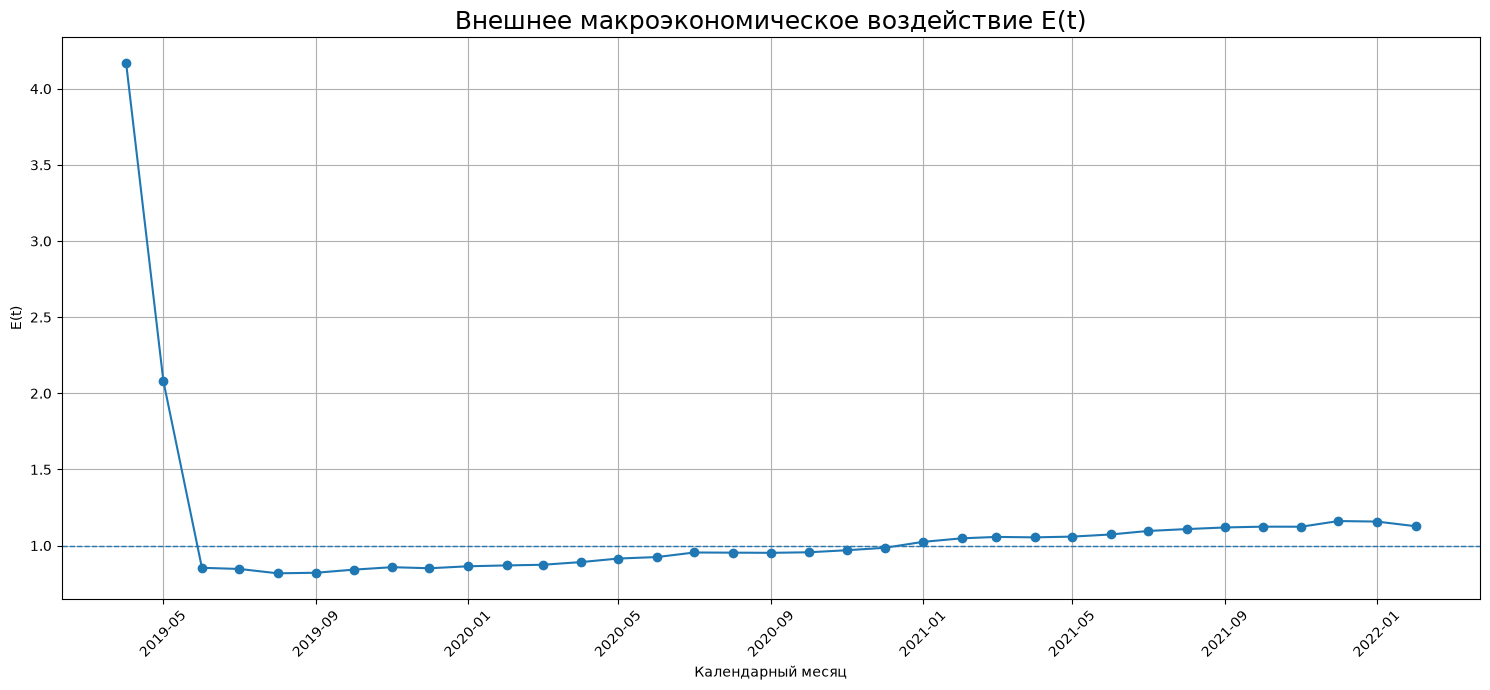

In [132]:
external = res["external_data"].copy()

value_columns = [
    col
    for col in external.columns
    if col != "month_dt"
]

external["E_mean"] = (
    external[value_columns]
    .mean(axis=1)
)

plt.figure(figsize=(15, 7))

plt.plot(
    external["month_dt"],
    external["E_mean"],
    marker="o"
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Внешнее макроэкономическое воздействие E(t)",
    fontsize=18
)

plt.xlabel("Календарный месяц")
plt.ylabel("E(t)")

plt.grid()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Наибольшее отклонение от E = 1 наблюдается в апреле и мае 2019 года, что может свидетельствовать о каком-то внешнем воздействии. Погуглив, я не смог найти никаких супер больших кризизов/факторов, которые могли повлечь такой скачок. 

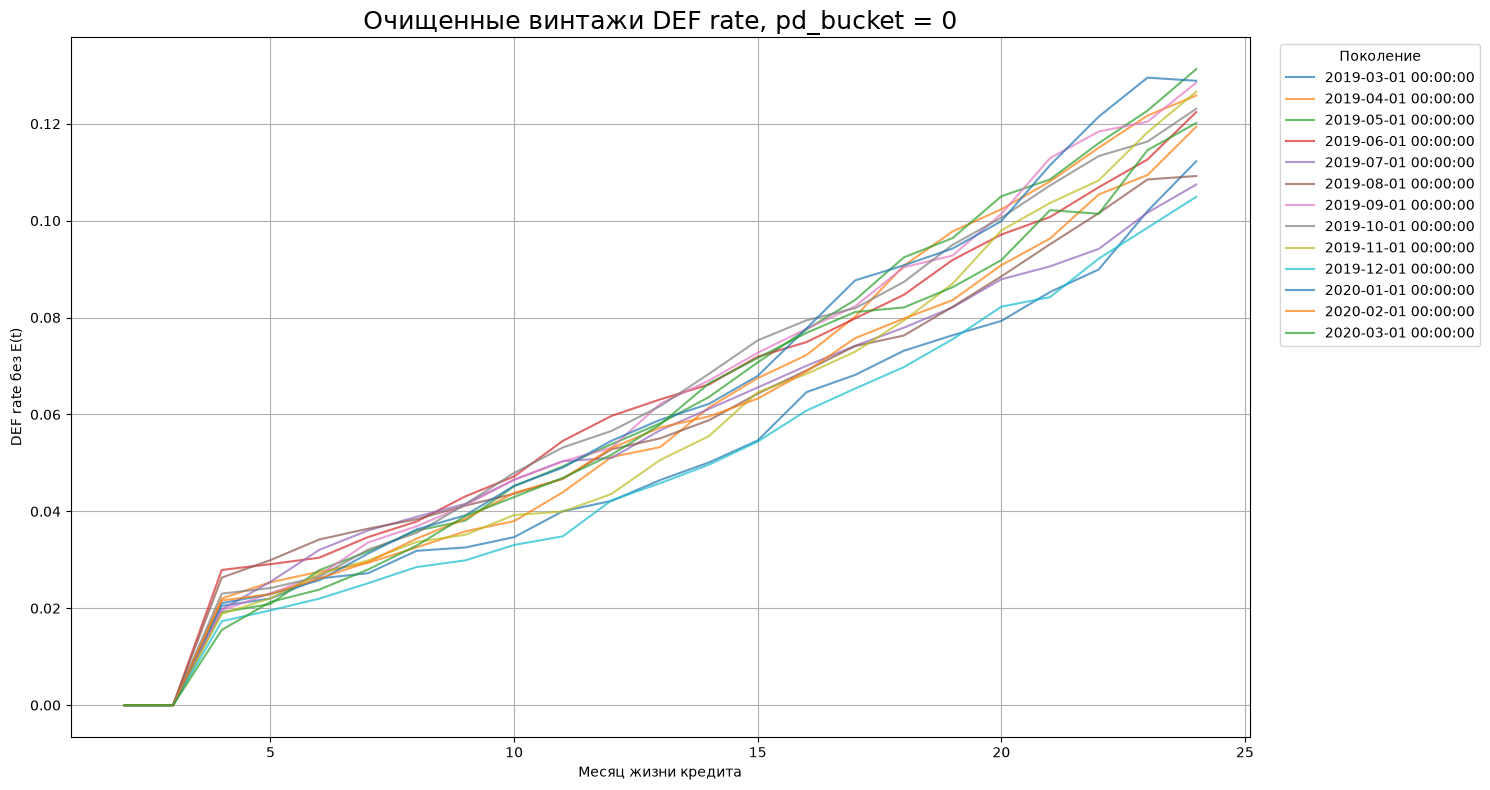

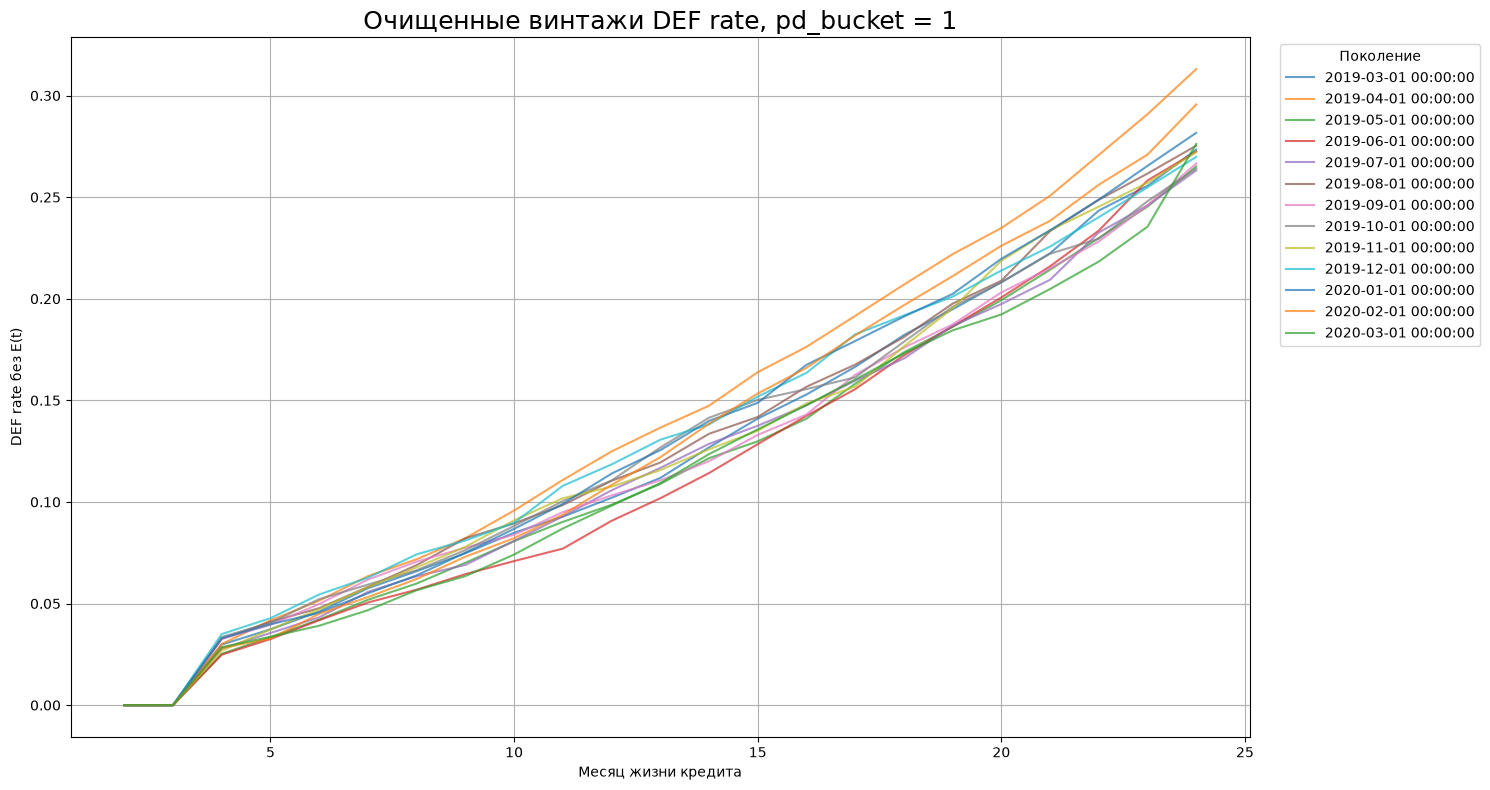

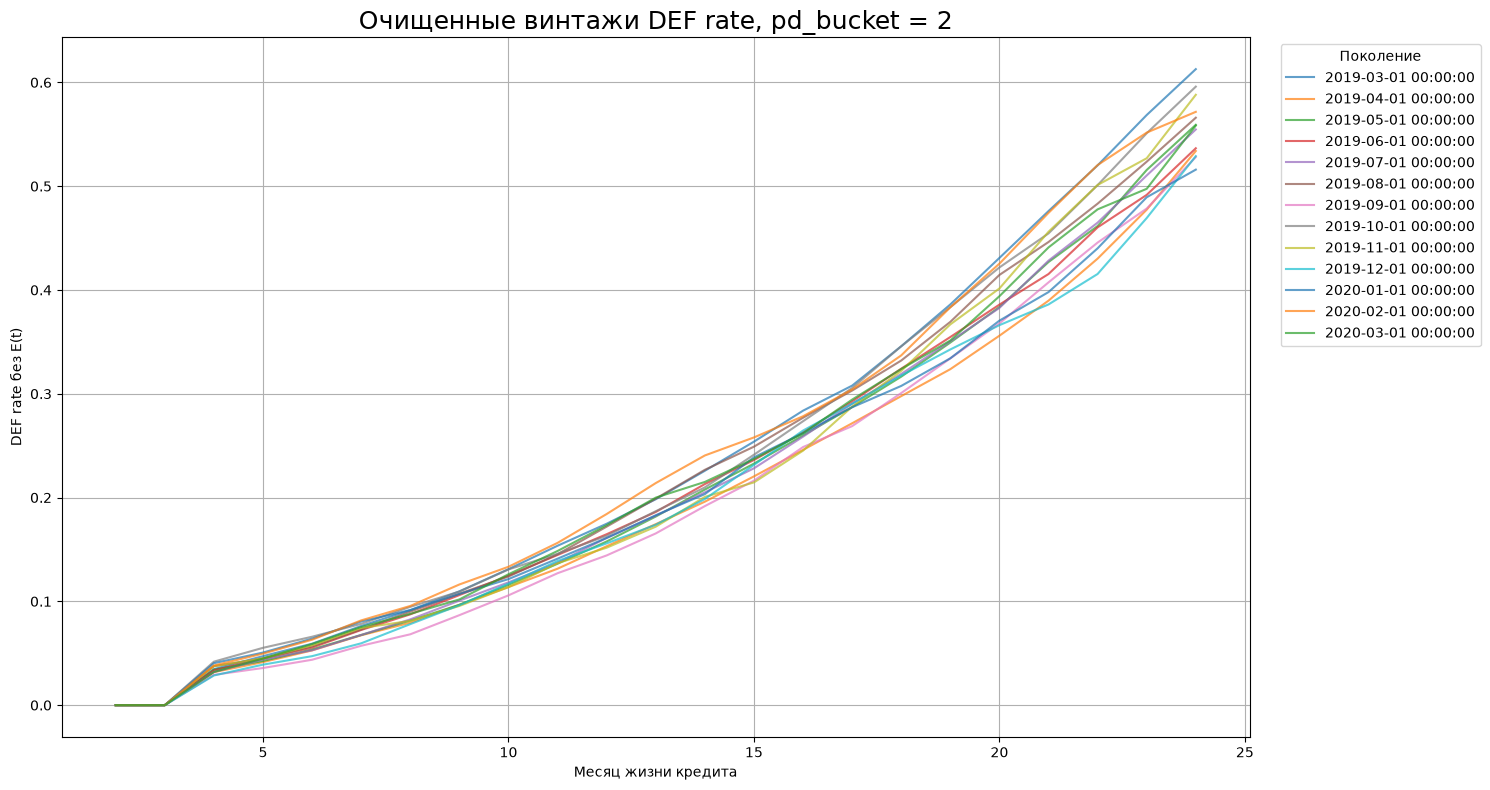

In [135]:
for bucket_value in sorted(
    res["fitted_data"]['pd_bucket'].unique()
):

    tmp = (
        res["fitted_data"]
        .query(
            f"{'pd_bucket'} == @bucket_value"
        )
        .pivot(
            index="statement_num",
            columns="gen_month_dt",
            values="fitted_feature"
        )
    )

    tmp.plot(
        figsize=(15, 8),
        grid=True,
        lw=1.5,
        alpha=0.7
    )

    plt.title(
        f"Очищенные винтажи DEF rate, "
        f"{'pd_bucket'} = {bucket_value}",
        fontsize=18
    )

    plt.xlabel("Месяц жизни кредита")
    plt.ylabel("DEF rate без E(t)")
    plt.legend(
        title="Поколение",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

### Среднее по бакетам (0.5 баллов) 
Выбери один из способой нахождение средней кривой (возможные способы указаны в лекции). Обоснуй свой выбор.

Реализуй функцию построения среднего.

In [149]:
def_rate_mean = (
    res["fitted_data"]
    .groupby(
        [
            'pd_bucket',
            "statement_num"
        ]
    )["fitted_feature"]
    .mean()
    .rename("mean_def_rate")
    .reset_index()
)

def_rate_mean.head()

,pd_bucket,statement_num,mean_def_rate
0,0,2,0.000000
1,0,3,0.000000
2,0,4,0.020970
3,0,5,0.023753
4,0,6,0.027407


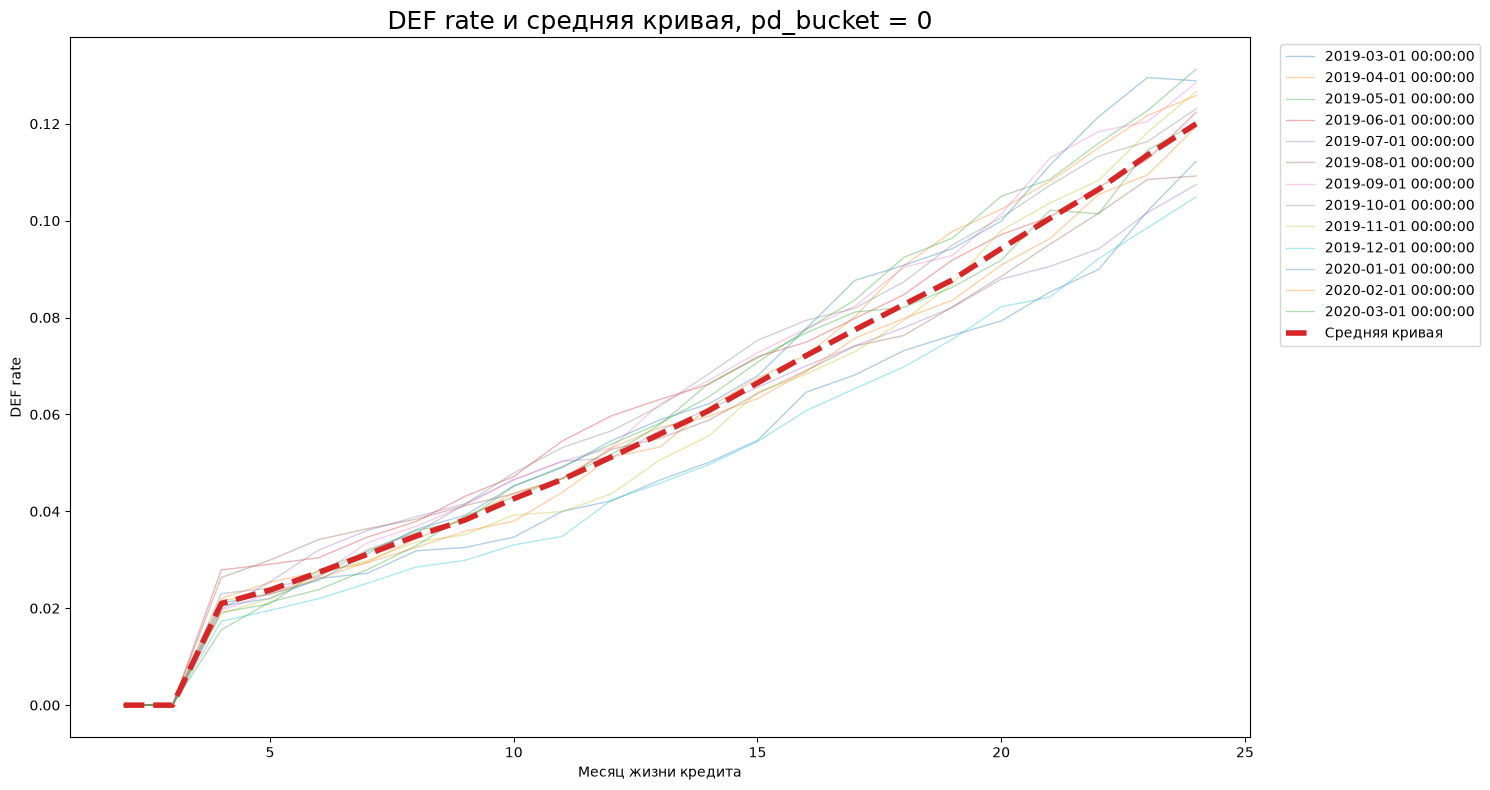

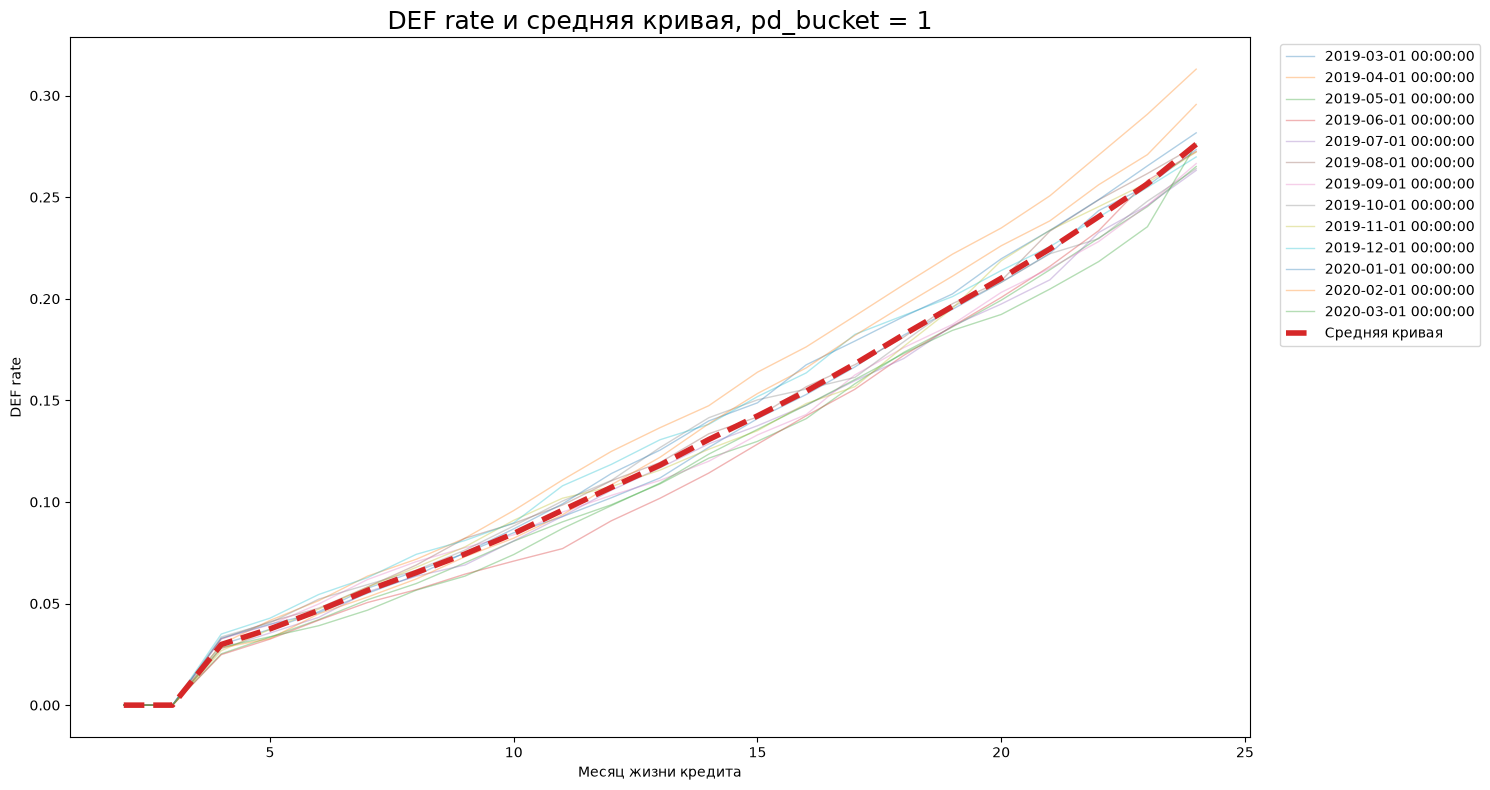

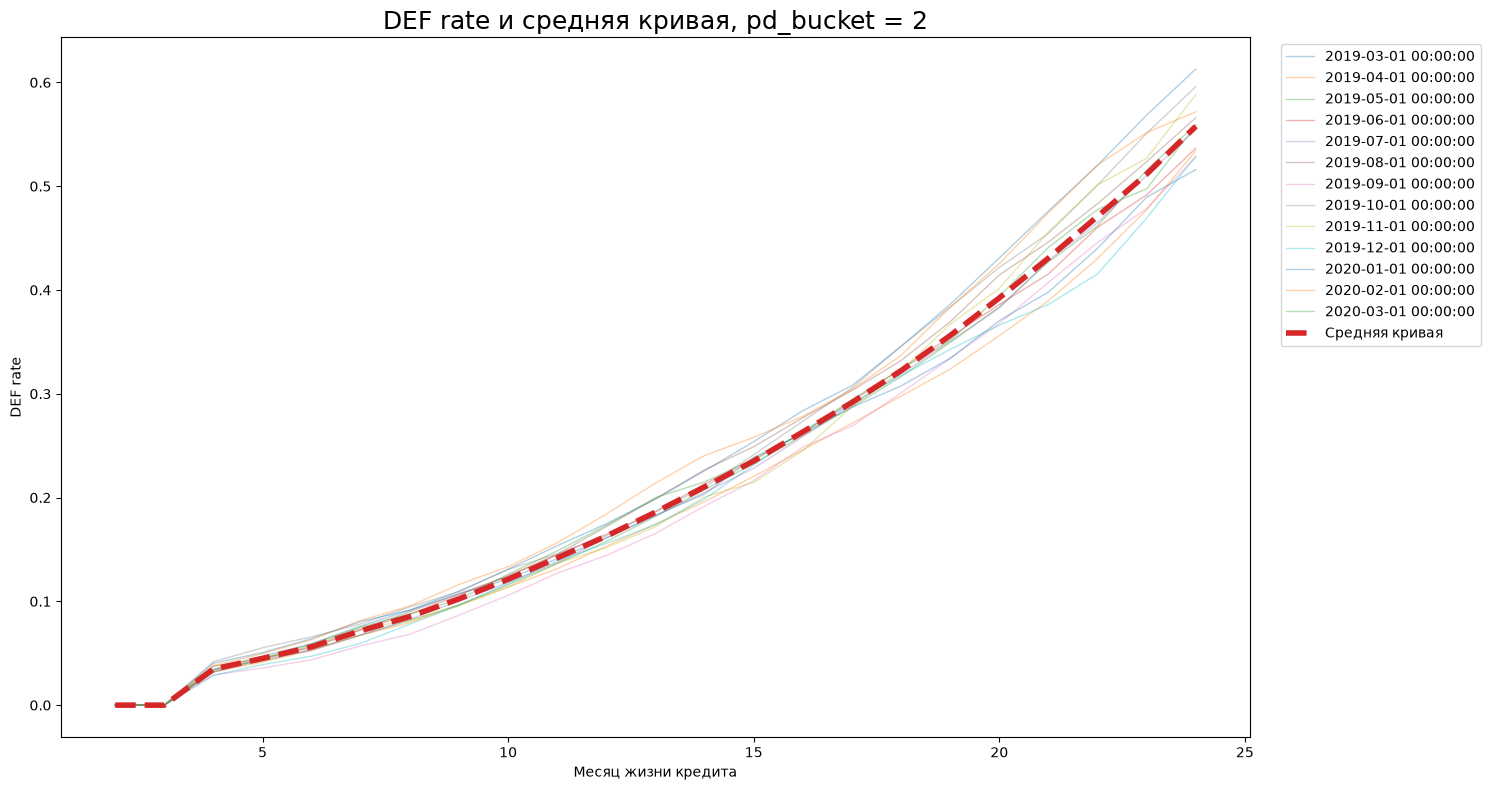

In [150]:
def plot_def_rate_mean(
    data,
    bucket,
    bucket_value
):

    vintages = (
        data
        .query(f"{bucket} == @bucket_value")
        .pivot(
            index="statement_num",
            columns="gen_month_dt",
            values="fitted_feature"
        )
    )

    mean_curve = (
        def_rate_mean
        .query(
            f"{bucket} == @bucket_value"
        )
        .set_index("statement_num")[
            "mean_def_rate"
        ]
    )

    vintages.plot(
        figsize=(15, 8),
        grid=True,
        lw=1,
        alpha=0.35
    )

    mean_curve.plot(
        lw=4,
        linestyle="--",
        label="Средняя кривая"
    )

    plt.title(
        f"DEF rate и средняя кривая, "
        f"{bucket} = {bucket_value}",
        fontsize=18
    )

    plt.xlabel("Месяц жизни кредита")
    plt.ylabel("DEF rate")

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


for bucket_value in sorted(
    df['pd_bucket'].unique()
):

    plot_def_rate_mean(
        res["fitted_data"],
        'pd_bucket',
        bucket_value
    )

### Сглаживание средних кривых (0.5 баллов) 

Рассмотри несколько функций для сглаживания кривой (можешь взять готовые из семинара, либо реализовать свои).

In [ ]:
def linear_approximation(series, start=5, finish=None):
    if finish is None:
        finish = len(series)  # по умолчанию до конца
    result = series.copy()
    
    # Индексы для обучения: все индексы между start и finish включительно
    train_indices = series.index[(series.index >= start) & (series.index <= finish)]
    if len(train_indices) == 0:
        raise ValueError("Нет данных для обучения")
    
    x_train = train_indices.astype(float).values
    y_train = series.loc[train_indices].values
    coeff = np.polyfit(x_train, y_train, 1)
    model = np.poly1d(coeff)
    
    # Заменяем на обучающем отрезке
    result.loc[train_indices] = model(x_train)
    
    # Хвост: все индексы > finish
    tail_indices = series.index[series.index > finish]
    if len(tail_indices) > 0:
        result.loc[tail_indices] = model(tail_indices.astype(float))
    
    return result


def polynomial_approximation(series, start=5, finish=None, degree=2):
    if finish is None:
        finish = len(series)
    result = series.copy()
    
    train_indices = series.index[(series.index >= start) & (series.index <= finish)]
    if len(train_indices) == 0:
        raise ValueError("Нет данных для обучения")
    
    x_train = train_indices.astype(float).values
    y_train = series.loc[train_indices].values
    coeff = np.polyfit(x_train, y_train, degree)
    model = np.poly1d(coeff)
    
    result.loc[train_indices] = model(x_train)
    
    tail_indices = series.index[series.index > finish]
    if len(tail_indices) > 0:
        result.loc[tail_indices] = model(tail_indices.astype(float))
    
    return result


def exponential_smoothing(series, start=5, alpha=0.25):
    result = series.copy()
    indices = series.index[series.index > start]
    for idx in indices:
        prev_idx = idx - 1 
        if prev_idx in result.index:
            result.loc[idx] = alpha * series.loc[idx] + (1 - alpha) * result.loc[prev_idx]
        else:
            result.loc[idx] = series.loc[idx]
    return result

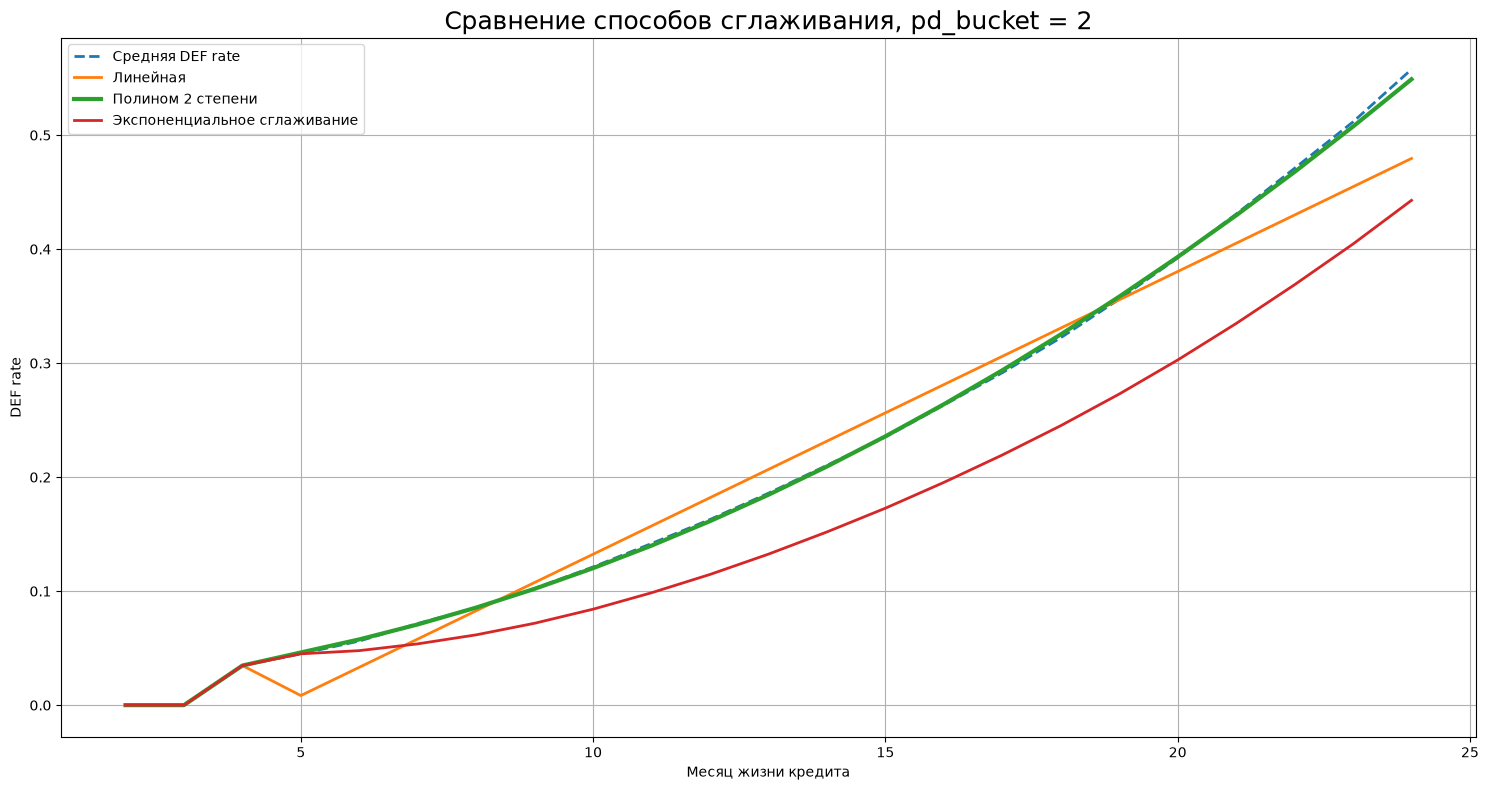

In [167]:
test_bucket = sorted(
    df['pd_bucket'].unique()
)[-1]

test_curve = (
    def_rate_mean
    .query(
        f"{'pd_bucket'} == @test_bucket"
    )
    .set_index("statement_num")[
        "mean_def_rate"
    ]
)

linear_curve = linear_approximation(
    test_curve,
    start=5,
    finish=min(22, len(test_curve))
)

polynomial_curve = polynomial_approximation(
    test_curve,
    start=5,
    finish=min(22, len(test_curve)),
    degree=2
)

smooth_curve = exponential_smoothing(
    test_curve,
    start=5,
    alpha=0.25
)

plt.figure(figsize=(15, 8))

test_curve.plot(
    linestyle="--",
    lw=2,
    label="Средняя DEF rate"
)

linear_curve.plot(
    lw=2,
    label="Линейная"
)

polynomial_curve.plot(
    lw=3,
    label="Полином 2 степени"
)

smooth_curve.plot(
    lw=2,
    label="Экспоненциальное сглаживание"
)

plt.title(
    f"Сравнение способов сглаживания, "
    f"{'pd_bucket'} = {test_bucket}",
    fontsize=18
)

plt.xlabel("Месяц жизни кредита")
plt.ylabel("DEF rate")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#### Вывод: укажи выбранную функцию и обоснуй свой выбор. Были ли точки, к которым не применил(-a) сглаживание? Почему?

Как видно из графика - среднее и полином 2 степени практически совпадают и обеспечивают наилучшее сглаживание, поэтому я выберу полином из-за возможности экстраполировать данные дальше. Такое получилось, скорее всего, из-за того, что данные в принципе уже достаточно гладкие. Я не применял сглаживание к первым четырем месяцам, потому что особые точки в начале кривой могут быть содержательно важны (это проговаривалось на занятии)

### Отрисуй сглаженные кривые по всем трем бакетам PD

In [168]:
smooth_def_rates = pd.DataFrame()

for bucket_value in sorted(
    def_rate_mean['pd_bucket'].unique()
):

    curve = (
        def_rate_mean
        .query(
            f"{'pd_bucket'} == @bucket_value"
        )
        .set_index("statement_num")[
            "mean_def_rate"
        ]
    )

    smooth_def_rates[
        bucket_value
    ] = polynomial_approximation(
        curve,
        start=5,
        finish=min(22, len(curve)),
        degree=2
    )

smooth_def_rates

,0,1,2
statement_num,,,
2,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000
4,0.020970,0.029845,0.034740
5,0.023829,0.037997,0.046219
6,0.027239,0.046588,0.057674
7,0.030832,0.055591,0.070797
8,0.034608,0.065007,0.085586
9,0.038568,0.074836,0.102044
10,0.042712,0.085077,0.120169


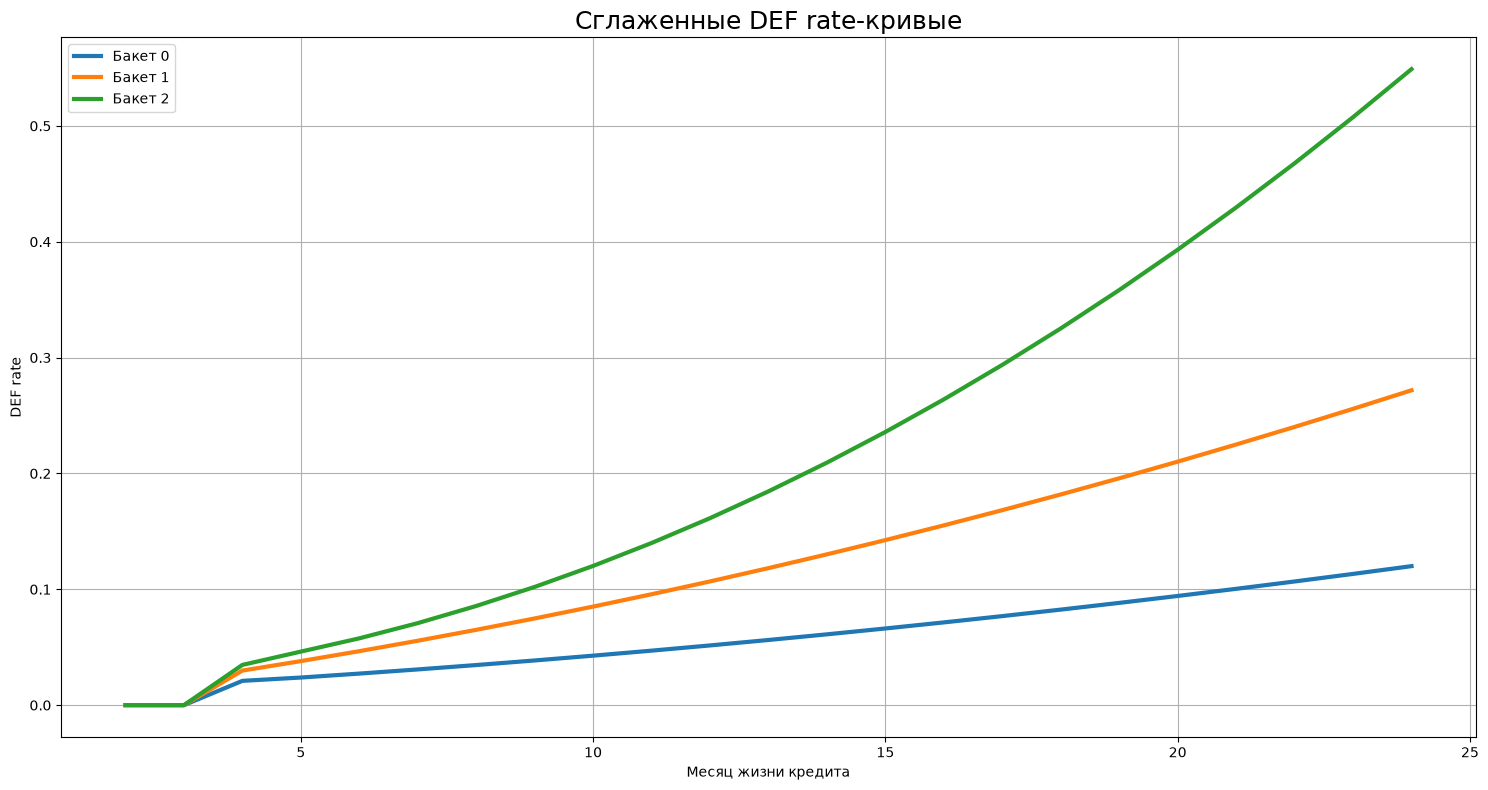

In [169]:
plt.figure(figsize=(15, 8))

for bucket_value in smooth_def_rates.columns:

    plt.plot(
        smooth_def_rates.index,
        smooth_def_rates[bucket_value],
        lw=3,
        label=f"Бакет {bucket_value}"
    )

plt.title(
    "Сглаженные DEF rate-кривые",
    fontsize=18
)

plt.xlabel("Месяц жизни кредита")
plt.ylabel("DEF rate")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Внедрение в NPV-модель

## Добавь в NPV-модель метод с расчетом DEF rate по твоей кривой

In [173]:
# Код NPV-модели с прошлого семинара

import numpy as np

class NPVModel:

    avg_missed_payments = 1.5
    recovery = 0.50
    dlq_penalty_amount = 500
    oper_costs = 100
    collection_costs = 600
    tax_rate = 0.20
    discounting_rate = 0.30
    eq_req = 0.125
    cost_of_funds = 0.16
    dlq_ratio = np.ones(101)*0.20
    dlq_ratio[0] = 0
    shift = 4
    clo_rate = 1 / (np.arange(shift, shift + 101) ** 2)
    acquisition_cost = 1000

    def __init__(self):
        pass

    def model_balance_calculations(self, amount, rate, term):
        '''
        Расчет модельных баланса, выплаченных процентов, регулярного платежа
        :param amount: Сумма кредита
        :param rate: Ставка
        :param term: Срок
        :return:
        balance : np.array(101) : остаток тела долга по кредиту на каждый месяц
        interest : np.array(101) : выплата по процентам каждый месяц
        regular_payment : float : размер регулярного платежа
        '''

        regular_payment = round(amount * (rate / 12) *\
                                (1 + (rate / 12)) / (1 - ((1 + rate / 12) ** (-term))))
        # График баланса и процентов
        balance = np.zeros(101)
        interest = np.zeros(101)
        balance[0] = amount

        for i in range(1, term + 1):
            int_payment = balance[i - 1] * rate / 12
            debt_payment = regular_payment - int_payment
            balance[i] = max(0, round(balance[i - 1] - debt_payment))
            interest[i] = int_payment
        return balance, interest, regular_payment

    def distribution_calc(self, portfolio_distribution, pd=None, pa=None):
        '''
        Расчет распределения по статусам
        :param portfolio_distribution: график распределения по статусам
        :return:
        cur_dist : np.array(101) : доля клиентов в статусе CUR на каждый месяц
        dlq_dist : np.array(101) : доля клиентов в статусе DLQ на каждый месяц
        act_dist : np.array(101) : доля клиентов в статусе ACT на каждый месяц
        def_dist : np.array(101) : доля клиентов в статусе DEF на каждый месяц
        clo_dist : np.array(101) : доля клиентов в статусе CLO на каждый месяц
        '''
        
        cur_dist = portfolio_distribution['CUR']
        dlq_dist = portfolio_distribution['DLQ']
        act_dist = cur_dist + dlq_dist
        def_dist = portfolio_distribution['DEF'] 
        clo_dist = portfolio_distribution['CLO']


        return cur_dist, dlq_dist, act_dist, def_dist, clo_dist

    def cur_balance_calc(self, model_balance, cur_dist):
        '''
        Расчет модельного баланса в статусе CUR
        :param model_balance: плановый график баланса
        :param cur_dist: доля клиентов в статусе CUR на каждый месяц
        :return:
        principal_balance_cur : np.array(101) : principal balance в статусе CUR
        gross_balance_cur : np.array(101) : gross balance в статусе CUR
        '''
        principal_balance_cur = model_balance*cur_dist
        gross_balance_cur = model_balance*cur_dist
        return principal_balance_cur, gross_balance_cur

    def dlq_balance_calc(self, model_balance, regular_payment, dlq_dist):
        '''
        Расчет модельного баланса в статусе DLQ
        :param model_balance: плановый график баланса
        :param regular_payment: размер регулярного платежа
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        principal_balance_dlq : np.array(101) : principal balance в статусе DLQ
        gross_balance_dlq : np.array(101) : gross balance в статусе DLQ
        '''
        principal_balance_dlq = np.append(model_balance[1:], model_balance[-1])*dlq_dist
        gross_balance_dlq = (model_balance + regular_payment*self.avg_missed_payments)*dlq_dist
        return principal_balance_dlq, gross_balance_dlq

    def act_balance_calc(self, principal_balance_cur, principal_balance_dlq, gross_balance_cur, gross_balance_dlq):
        '''
        Расчет модельного баланса в статусе ACT
        :param principal_balance_cur: principal balance в статусе CUR
        :param principal_balance_dlq: principal balance в статусе DLQ
        :param gross_balance_cur: principal balance в статусе CUR
        :param gross_balance_dlq: principal balance в статусе DLQ
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        principal_balance_act : np.array(101) : principal balance в статусе ACT
        gross_balance_act : np.array(101) : gross balance в статусе ACT
        '''
        principal_balance_act = principal_balance_cur + principal_balance_dlq
        gross_balance_act = gross_balance_cur + gross_balance_dlq
        return principal_balance_act, gross_balance_act

    def def_balance_calc(self, model_balance, regular_payment, def_dist):
        '''
        Расчет модельного баланса в статусе DEF
        :param model_balance: плановый график баланса
        :param regular_payment: размер регулярного платежа
        :param def_dist: доля клиентов в статусе DEF на каждый месяц
        :return:
        principal_balance_def : np.array(101) : principal balance в статусе DEF
        gross_balance_def : np.array(101) : gross balance в статусе DEF
        '''
        principal_balance_def = np.zeros(101)
        gross_balance_def = np.zeros(101)

        def_dist_change = def_dist[4:] - def_dist[3:-1]
        principal_balance_def[4:] = np.cumsum(model_balance[:-4] * def_dist_change)
        gross_balance_def[4:] = np.cumsum((model_balance[4:] + 4 * regular_payment) * def_dist_change)

        return principal_balance_def, gross_balance_def

    def profit_calc(self, principal_balance_act, principal_balance_def, term, rate, dlq_dist):
        '''

        :param principal_balance_act: principal balance в статусе ACT
        :param principal_balance_def: principal balance в статусе DEF
        :param term: срок кредита
        :param rate: тавка по кредиту
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        profit : np.array(101) : доход на каждый месяц
        '''
        interest_profit = principal_balance_act*rate/12
        penatly_profit = dlq_dist*self.dlq_penalty_amount

        new_def_balance = np.append(principal_balance_def[1:], 0) - principal_balance_def
        recovery_profit = new_def_balance*self.recovery

        profit = interest_profit + recovery_profit + penatly_profit
        profit[term+1:] = 0

        return profit

    def loss_calc(self, gross_balance_act, principal_balance_def, term, act_dist, dlq_dist, def_dist):
        '''

        :param gross_balance_act: gross balance в статусе ACT
        :param principal_balance_def: principal balance в статусе DEF
        :param term: срок кредита
        :param act_dist: доля клиентов в статусе ACT на каждый месяц
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :param def_dist: доля клиентов в статусе DEF на каждый месяц
        :return:
        loss : np.array(101) : лосс на каждый месяц
        '''
        oper_loss = np.append(act_dist[1:], 0)*self.oper_costs
        loan_loss =  principal_balance_def - np.append(0, principal_balance_def[:-1])
        collection_loss = (np.append(dlq_dist[1:], 0) + np.append(def_dist[1:], 0))*self.collection_costs

        prev_gross_balance_act = np.append(gross_balance_act[0], gross_balance_act[1:])
        cost_of_funds_loss = prev_gross_balance_act*(1 - self.eq_req)*self.cost_of_funds/12

        loss = loan_loss + cost_of_funds_loss + oper_loss + collection_loss
        loss[term+1:] = 0

        return loss, loan_loss, cost_of_funds_loss, oper_loss, collection_loss

    def assets_liabilities_calc(self, gross_balance_act):
        '''

        :param gross_balance_act: gross balance в статусе ACT
        :return:
        assets : np.array(101) : активы в проекте
        eq_req_curve : np.array(101) : активы, обеспеченные капиталом
        fund_req_curve : np.array(101) : активы, обеспеченные фондами
        '''

        # assets
        assets = gross_balance_act

        #liabilities
        eq_req_curve = assets*self.eq_req
        fund_req_curve = assets*(1 - self.eq_req)

        return assets, eq_req_curve, fund_req_curve

    def niat_calc(self, profit, loss):
        '''
        Расчет NIAT
        :param profit: суммарный доход на каждый месяц
        :param loss: суммарный лосс на каждый месяц
        :return:
        nibt : np.array(101) : прибыль до налогообложения
        niat : np.array(101) : прибыль после налогообложения
        tax : np.array(101) : налог в каждом месяце
        '''

        nibt = profit - loss
        tax = nibt*self.tax_rate
        niat = nibt - tax

        return nibt, niat, tax

    def cashflow_calc(self, principal_balance_act, principal_balance_def, amount, profit,
                      cost_of_funds_loss, oper_costs, collection_costs, tax, niat, eq_req_curve, fund_req_curve):
        '''
        Расчет денежных потоков
        :param principal_balance_act: principal balance в статусе DEF
        :param principal_balance_def: principal balance в статусе DEF
        :param amount: срок кредита
        :param profit: доход на каждый месяц
        :param cost_of_funds_loss: лоссы на фондирование
        :param oper_costs: операционные расходы
        :param collection_costs: расходы на коллекшн
        :param tax: налог в каждом месяце
        :param niat: доход после налогообложения
        :param eq_req_curve: активы, обеспеченные капиталом
        :param fund_req_curve: активы, обеспеченные фондами
        :return:
        cf_to_client : np.array(101) : денежный поток к клиенту
        cf_to_shareholders : np.array(101) : денежный поток к акционерам
        cf_to_debtholders : np.array(101) : денежный поток к фондам
        cf_to_cost_and_tax : np.array(101) : денежный поток на косты и налоги
        '''
        # client
        delta_principal_balance_act = (np.append(0, principal_balance_act[:100]) - principal_balance_act)
        delta_principal_balance_def = (np.append(0, principal_balance_def[:100]) - principal_balance_def)
        repayments = delta_principal_balance_act - delta_principal_balance_def + profit
        cf_to_client = np.append(amount, -repayments[1:])

        # debtoholder
        fund_req_ch = fund_req_curve - np.append(fund_req_curve[0], fund_req_curve[:-1])
        fund_req_change = np.append(fund_req_curve[0], fund_req_ch[1:])
        cf_to_debtholders = cost_of_funds_loss - fund_req_change

        # shareholders
        eq_req_ch = eq_req_curve - np.append(eq_req_curve[0], eq_req_curve[:-1])
        cf_to_shareholders = niat - np.append(eq_req_curve[0], eq_req_ch[1:])

        # cost and tax
        cf_to_cost_and_tax = oper_costs + collection_costs + tax

        return cf_to_client, cf_to_shareholders, cf_to_debtholders, cf_to_cost_and_tax
        
    def npv_calc(self, amount, rate, term, pd=None):
        '''
        Расчет NPV с внутренним вычислением portfolio_distribution
        :param amount: сумма кредита
        :param rate: ставка по кредиту
        :param term: срок кредита
        :param def_rate: доля дефолтных клиентов к концу срока
        :param clo_rate: доля закрытых клиентов к концу срока
        :param pd: вероятность дефолта к 12-ому месяцу
        :param pa: вероятность полного досрочного погашения к 6-ому месяцу
        :return: npv: чистая приведенная стоимость кредита
        '''

        # Считаем балансы
        model_balance, interest, regular_payment = self.model_balance_calculations(amount, rate, term)
        
        # Рассчитываем распределение по статусам
        cur_dist = np.zeros(101)
        dlq_dist = np.zeros(101)
        def_dist = np.zeros(101)
        clo_dist = np.zeros(101)
        act_dist = np.zeros(101)
        
        # В начале все клиенты в статусе CUR
        act_dist[0] = 1
        cur_dist[0] = 1
        
        self.def_rate = self.def_rate_calc(pd)
        
        for i in range(1, term + 1):
            clo_dist[i] = clo_dist[i - 1] + self.clo_rate[i] * act_dist[i - 1]
            def_dist[i] = def_dist[i - 1] + self.def_rate[i] * act_dist[i - 1]
            act_dist[i] = max(0, 1 - clo_dist[i] - def_dist[i])
            dlq_dist[i] = self.dlq_ratio[i] * act_dist[i]
            cur_dist[i] = act_dist[i] - dlq_dist[i]
            

        portfolio_distribution = {
            'CUR': cur_dist,
            'DLQ': dlq_dist,
            'DEF': def_dist,
            'CLO': clo_dist
        }

        # Считаем распределение
        cur_dist, dlq_dist, act_dist, def_dist, clo_dist = self.distribution_calc(portfolio_distribution)

        # Считаем балансы
        principal_balance_cur, gross_balance_cur = self.cur_balance_calc(model_balance, cur_dist)
        principal_balance_dlq, gross_balance_dlq = self.dlq_balance_calc(model_balance, regular_payment, dlq_dist)
        principal_balance_act, gross_balance_act = self.act_balance_calc(principal_balance_cur, principal_balance_dlq, gross_balance_cur, gross_balance_dlq)
        principal_balance_def, gross_balance_def = self.def_balance_calc(model_balance, regular_payment, def_dist)

        # Считаем профиты
        profit = self.profit_calc(principal_balance_act, principal_balance_def, term, rate, dlq_dist)
        loss, loan_loss, cost_of_funds_loss, oper_loss, collection_loss = self.loss_calc(gross_balance_act, principal_balance_def,
                                                                                        term, act_dist, dlq_dist, def_dist)
        nibt, niat, tax = self.niat_calc(profit, loss)

        # Считаем активы и денежные потоки
        assets, eq_req_curve, fund_req_curve = self.assets_liabilities_calc(gross_balance_act)
        cf_to_client, cf_to_shareholders, cf_to_debtholders, cf_to_cost_and_tax =\
            self.cashflow_calc(principal_balance_act, principal_balance_def, amount, profit, cost_of_funds_loss, oper_loss, collection_loss,
                            tax, niat, eq_req_curve, fund_req_curve)

        # Считаем NPV
        disc_curve = np.array([1 / ((1 + self.discounting_rate) ** (i / 12.)) for i in range(101)])
        pv = np.round(np.sum(disc_curve * cf_to_shareholders)).astype(int)
        npv = pv - self.acquisition_cost

        return npv
    
    
    def def_rate_calc(self, pd=None):

        if pd is None:
            raise ValueError("Для расчета DEF rate необходимо передать PD.")

        # Определяем бакет клиента
        bucket = np.digitize(pd, self.pd_edges[1:-1], right=True)
        bucket = int(np.clip(bucket, 0, len(self.def_curves) - 1))

        # Получаем кривую соответствующего бакета
        def_rate = self.def_curves[bucket].copy()

        # Первый месяц — начальная точка
        def_rate[0] = 0

        # За пределами доступной кривой используем последнее доступное значение.
        if len(def_rate) < 101:
            last_value = def_rate[np.nonzero(def_rate)[0][-1]]
            def_rate[len(def_rate):] = last_value

        return def_rate

In [174]:
# Сохраняем кривые в формате: bucket -> массив DEF rate по месяцам

def_curves_for_npv = {
    int(bucket): smooth_def_rates[bucket].to_numpy()
    for bucket in smooth_def_rates.columns
}

# Нумерация месяцев начинается с 1, а NPV-модель использует массив длины 101.
npv_def_curves = {}
for bucket, curve in def_curves_for_npv.items():

    arr = np.zeros(101)
    max_month = min(len(curve), 100)

    arr[1:max_month + 1] = curve[:max_month]
    # После последнего наблюдаемого месяц используем последнее значение кривой.
    if max_month < 100:
        arr[max_month + 1:] = arr[max_month]

    npv_def_curves[bucket] = arr

npv_def_curves

{0: array([0.        , 0.        , 0.        , 0.02097031, 0.02382947,
        0.0272389 , 0.03083185, 0.03460833, 0.03856835, 0.04271189,
        0.04703896, 0.05154957, 0.0562437 , 0.06112136, 0.06618256,
        0.07142728, 0.07685553, 0.08246732, 0.08826263, 0.09424148,
        0.10040385, 0.10674975, 0.11327919, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0.11999215, 0.11999215,
        0.11999215, 0.11999215, 0.11999215, 0

In [175]:
def calculate_bucket_edges(scores, score_column="pd", n_buckets=3):

    values = np.sort(scores[score_column].dropna().to_numpy())
    quantiles = np.linspace(0, 1, n_buckets + 1)
    edges = np.quantile(values, quantiles)
    edges = np.unique(edges)

    return edges

pd_edges = calculate_bucket_edges(df_scores, "pd", 3)
print("Границы PD-бакетов:")
print(pd_edges)

Границы PD-бакетов:
[0.00025183 0.02079817 0.04631634 0.09999723]


In [176]:
# По значению PD определяем бакет и возвращаем соответствующую DEF rate-кривую.
def def_rate_by_score(score, score_edges, curves):

    bucket = np.digitize(score, score_edges[1:-1], right=True)
    bucket = int(np.clip(bucket, 0, len(curves) - 1))

    return curves[bucket]

In [177]:
model = NPVModel()

model.def_curves = npv_def_curves
model.pd_edges = pd_edges

print("NPV-модель подготовлена.")
print("Количество DEF-кривых:", len(model.def_curves))
print("Границы PD:", model.pd_edges)

NPV-модель подготовлена.
Количество DEF-кривых: 3
Границы PD: [0.00025183 0.02079817 0.04631634 0.09999723]


In [178]:
test_pds = np.linspace(
    df_scores["pd"].min(),
    df_scores["pd"].max(),
    5
)

for pd_value in test_pds:

    curve = model.def_rate_calc(
        pd_value
    )

    print(
        f"PD = {pd_value:.4f} | "
        f"DEF rate месяц 12 = {curve[12]:.6f}"
    )

PD = 0.0003 | DEF rate месяц 12 = 0.056244
PD = 0.0252 | DEF rate месяц 12 = 0.118277
PD = 0.0501 | DEF rate месяц 12 = 0.184548
PD = 0.0751 | DEF rate месяц 12 = 0.184548
PD = 0.1000 | DEF rate месяц 12 = 0.184548


## Посчитай NPV по кредиту с параметрами

- Срок кредита 2 года
- Годовая процентная ставка 21%
- Сумма кредита 1 млн
- Страховка подключена

In [180]:
amount = 1_000_000
rate = 0.21
term = 24

example_pd = df_scores["pd"].median()
npv = model.npv_calc(
    amount=amount,
    rate=rate,
    term=term,
    pd=example_pd
)

print(f"PD клиента: {example_pd:.4f}")
print(f"NPV кредита: {npv:,.0f} руб.")

PD клиента: 0.0323
NPV кредита: -188,651 руб.


## Построй график зависимости NPV от скора, которым ты побил(-а) DEF rate

In [183]:
pd_values = np.linspace(
    df_scores["pd"].quantile(0.01),
    df_scores["pd"].quantile(0.99),
    20
)

npv_values = []

for pd_value in pd_values:

    npv_value = model.npv_calc(
        amount=1_000_000,
        rate=0.21,
        term=24,
        pd=pd_value
    )

    npv_values.append(
        npv_value
    )

npv_table = pd.DataFrame({
    "pd": pd_values,
    "npv": npv_values
})

npv_table.head()

,pd,npv
0,0.001931,-129629
1,0.006939,-129629
2,0.011946,-129629
3,0.016953,-129629
4,0.021960,-188651


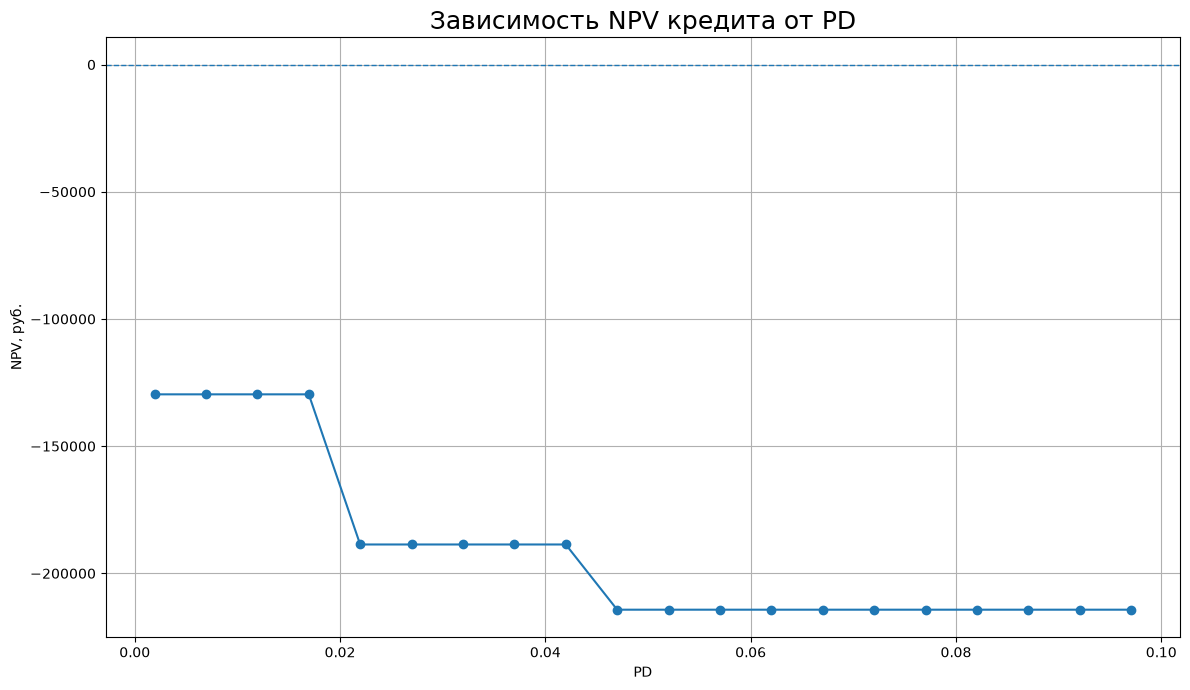

In [182]:
plt.figure(figsize=(12, 7))

plt.plot(
    npv_table["pd"],
    npv_table["npv"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Зависимость NPV кредита от PD",
    fontsize=18
)

plt.xlabel("PD")
plt.ylabel("NPV, руб.")

plt.grid()
plt.tight_layout()
plt.show()